In [9]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [10]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Apr  1 08:35:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 561.09                 Driver Version: 561.09         CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080      WDDM  |   00000000:0A:00.0  On |                  N/A |
|  0%   34C    P8             19W /  370W |    1331MiB /  10240MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [11]:
# !pip install boruta
# !pip install smote_variants
# !pip install lime
# !pip install signaturizer

In [12]:
#import default and other essential libraries
import os
import numpy as np
import pandas as pd
import sklearn
import joblib
import pickle
import csv
import sys
import random
import seaborn as sns
from functools import reduce
import matplotlib.backends.backend_pdf
import matplotlib.pyplot as plt
import tensorflow as tf

In [13]:
#Packages to split data and other preprocessing
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn import metrics
from sklearn.feature_selection import VarianceThreshold
from sklearn.base import BaseEstimator,TransformerMixin
from sklearn.decomposition import PCA
from boruta import BorutaPy
from imblearn.pipeline import Pipeline as sample_pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

In [14]:
#Import Classifiers
from sklearn import svm
import smote_variants as sv
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

In [15]:
## Package for calculating accuracy and analysis
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import roc_curve, auc, accuracy_score, roc_auc_score, cohen_kappa_score, f1_score, precision_score, recall_score, matthews_corrcoef
from sklearn.model_selection import StratifiedKFold
from lime.lime_tabular import LimeTabularExplainer

In [16]:
from signaturizer import Signaturizer
from tqdm import tqdm

In [17]:
def handle_missing_values(data):
    print('Handling missing values')
    data = data.replace([np.inf, -np.inf, "", " "], np.nan)
    data = data.replace(["", " "], np.nan)
    for i in data.columns:
        data[i] = data[i].fillna(data[i].mean())
    return data

def Feature_Signaturizer(dat):
    sig_df=pd.DataFrame()
    desc=['A','B','C','D','E']
    for dsc in tqdm(desc):
        for i in range(1,6):
            sign = Signaturizer(dsc+str(i), local=True)
            results = sign.predict(dat)
            df=pd.DataFrame(results.signature)
            for clm in list(df.columns):
                df=df.rename(columns={clm:dsc+str(i)+'_'+str(clm)})
            sig_df=pd.concat([sig_df,df],axis = 1)
    sig_df = handle_missing_values(sig_df)
    res = pd.DataFrame()
    res['smiles'] = dat
    res = pd.concat([res,sig_df],axis = 1)
    return res

In [18]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/Zz/Desktop/致癌性课题/00. 机器学习相关内容/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'AID_1189_datatable_all.csv') ### features in columns,molecules in rows
# 1. 根据列名为 PUBCHEM_CID 的取值去除重复的
data = data.drop_duplicates(subset='PUBCHEM_CID')

# 2. 替换 PUBCHEM_ACTIVITY_OUTCOME 列的取值
data['PUBCHEM_ACTIVITY_OUTCOME'] = data['PUBCHEM_ACTIVITY_OUTCOME'].replace({
    'Active': 1,
    'Inactive': 0,
    'Unspecified': np.nan
})

# 将 'Status' 列名修改为 'status'
data = data.rename(columns={'PUBCHEM_ACTIVITY_OUTCOME': 'status'})

# 3. 删除 SMILES 和 PUBCHEM_ACTIVITY_OUTCOME 两列中任一有空值的行
data = data.dropna(subset=['SMILES', 'status'])

# 4. 重新设置索引
data.reset_index(drop=True, inplace=True)

# 输出处理后的数据
data

,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,SMILES,status
0,4,48413127,62805.0,C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N,1.0
1,5,48413128,11074431.0,CC1=CC(=O)[N-]S(=O)(=O)O1.[K+],0.0
2,6,48413129,177.0,CC=O,1.0
3,7,48413130,9548611.0,C/C=N/N(C)C=O,1.0
4,8,48413131,5324279.0,C/C=N/O,0.0
...,...,...,...,...,...
1472,1543,48414669,4343483.0,[B-](F)(F)(F)F.[Na+],0.0
1473,1544,48414670,9352.0,CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C,0.0
1474,1545,48414671,31703.0,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,0.0
1475,1546,48414672,5459896.0,C/[N+](=N/CO[C@H]1[C@@H]([C@H]([C@@H]([C@H](O1...,1.0


In [19]:
# 提取 SMILES 列
data_smiles = data['SMILES']
# 使用 Feature_Signaturizer 计算特征
data_features = Feature_Signaturizer(data_smiles)

  0%|                                                                                            | 0/5 [00:00<?, ?it/s]
Parsing SMILES: 0it [00:00, ?it/s]
Parsing SMILES: 1477it [00:00, 8295.89it/s][A

Generating signatures:   0%|                                                                    | 0/12 [00:00<?, ?it/s]

1/1 [==============================] - 0s 49ms/step



Generating signatures:   8%|█████                                                       | 1/12 [00:00<00:04,  2.47it/s]

1/1 [==============================] - 0s 21ms/step



Generating signatures:  17%|██████████                                                  | 2/12 [00:00<00:03,  3.06it/s]

...

1/1 [==============================] - 0s 22ms/step



Generating signatures:  92%|██████████████████████████████████████████████████████     | 11/12 [00:03<00:00,  3.60it/s]

1/1 [==============================] - 0s 52ms/step



100%|████████████████████████████████████████████████████████████████████████████████████| 5/5 [02:02<00:00, 24.44s/it]


Handling missing values


In [20]:
# 保留原始的 'status' 列
data = pd.concat([data_features, data['status']], axis=1)
data.to_csv('data_1189.csv')
# 打印查看结果
print(data)

                                                 smiles      A1_0      A1_1  \
0                      C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N  0.093736  0.085740   
1                        CC1=CC(=O)[N-]S(=O)(=O)O1.[K+] -0.100093 -0.099089   
2                                                  CC=O -0.093480 -0.089256   
3                                         C/C=N/N(C)C=O -0.098334 -0.081190   
4                                               C/C=N/O -0.094337 -0.094267   
...                                                 ...       ...       ...   
1472                               [B-](F)(F)(F)F.[Na+] -0.097991 -0.054415   
1473      CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C -0.081429  0.101074   
1474  C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...  0.094905  0.095126   
1475  C/[N+](=N/CO[C@H]1[C@@H]([C@H]([C@@H]([C@H](O1...  0.054064  0.094914   
1476  C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@@]2(C#C)O)CCC... -0.091836  0.091844   

          A1_2      A1_3      A1_4      A1_5      A

In [21]:
# dropping ALL duplicate values, if any
data.drop_duplicates(subset ="smiles", keep = 'first', inplace = True, ignore_index = True)
data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N,0.093736,0.085740,0.093669,-0.093734,-0.093736,-0.093322,0.093736,-0.093720,-0.093735,...,0.119303,-0.005264,-0.015739,-0.010548,0.022230,0.016731,0.094203,-0.123231,-0.099464,1.0
1,CC1=CC(=O)[N-]S(=O)(=O)O1.[K+],-0.100093,-0.099089,-0.084482,-0.094031,0.085663,0.100332,0.010700,-0.028889,0.082374,...,-0.014518,-0.108743,0.071680,0.064403,-0.096408,-0.119347,0.056990,0.105996,0.040380,0.0
2,CC=O,-0.093480,-0.089256,0.069821,-0.090986,-0.082047,-0.043311,0.091746,-0.093449,0.089063,...,-0.116392,0.065308,-0.059599,0.008411,-0.018177,-0.046910,-0.002472,0.137653,0.030367,1.0
3,C/C=N/N(C)C=O,-0.098334,-0.081190,0.049624,-0.061810,-0.066663,-0.022000,0.087457,-0.098039,0.047136,...,-0.059423,-0.026727,0.045251,-0.068311,0.028785,-0.068248,0.011206,0.146743,-0.091350,1.0
4,C/C=N/O,-0.094337,-0.094267,-0.061762,-0.030489,-0.084795,-0.086791,0.066033,-0.093190,0.083002,...,-0.104742,0.103060,0.032465,0.105356,-0.053154,0.019774,-0.092869,0.018223,0.047855,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1472,[B-](F)(F)(F)F.[Na+],-0.097991,-0.054415,-0.096213,0.073116,-0.087903,0.097987,0.097999,-0.097530,0.028544,...,0.039529,-0.066351,0.049006,-0.005755,-0.094299,-0.121235,0.153564,0.068159,0.045641,0.0
1473,CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C,-0.081429,0.101074,-0.099643,0.044534,-0.009886,0.103886,0.101898,-0.100953,-0.053132,...,0.068395,-0.097580,0.035865,0.006866,-0.021929,0.024656,0.098623,-0.101600,0.060218,0.0
1474,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,0.094905,0.095126,0.095131,-0.094879,0.095144,0.089254,0.094964,0.095148,0.062620,...,-0.104993,0.055505,0.112147,0.034025,-0.109840,0.092207,-0.108522,-0.065412,0.010985,0.0
1475,C/[N+](=N/CO[C@H]1[C@@H]([C@H]([C@@H]([C@H](O1...,0.054064,0.094914,0.095226,-0.094886,0.095226,-0.094630,0.066653,0.094706,0.069735,...,-0.100283,0.050642,0.060924,-0.064518,-0.068143,0.005452,-0.104746,0.049446,-0.033317,1.0


In [22]:
def Boruta_Filteration(X_train,y_train,X_test,y_test):
    #### making files for boruta
    features = [f for f in X_train.columns if f not in ['status']]
    X_train_boruta = X_train[features].values
    Y_train_boruta = y_train.values.ravel()
    X_test_boruta = X_test[features].values
    Y_test_boruta = y_test.values.ravel()

    print('Before filteration\nTrain shape\n',X_train_boruta.shape,'\nTest shape\n',X_test_boruta.shape)

    ### implementing boruta

    # define random forest classifier, with utilising all cores and
    # sampling in proportion to y labels
    rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5)

    # define Boruta feature selection method
    feat_selector = BorutaPy(rf, n_estimators=100, random_state=1)

    # find all relevant features - 5 features should be selected
    feat_selector.fit(X_train_boruta, Y_train_boruta)

    # check selected features - first 5 features are selected
    feat_selector.support_

    # check ranking of features
    feat_selector.ranking_

    # call transform() on X to filter it down to selected features
    X_train_filtered = feat_selector.transform(X_train_boruta)
    X_test_filtered = feat_selector.transform(X_test_boruta)

    ### name of the features selected####
    final_features = list()
    indexes = np.where(feat_selector.support_ == True)
    for x in np.nditer(indexes):
        final_features.append(features[x])

    print('# of Features selected:',len(final_features))

    X_train_filtered=pd.DataFrame(X_train_filtered,columns=final_features)
    X_test_filtered=pd.DataFrame(X_test_filtered,columns=final_features)

    print('After filteration\nTrain shape\n',X_train_filtered.shape,'\nTest shape\n',X_test_filtered.shape)

    return X_train_filtered,X_test_filtered,Y_train_boruta,Y_test_boruta,final_features

In [23]:
'''
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        #plt.legend(loc="lower right")
        plt.show()
'''

'\ndef TSNE_plot(data,data_labels):\n        tsne = TSNE(n_components=2, random_state=50)\n        transformed_data = tsne.fit_transform(data)\n        k = np.array(transformed_data)\n        Group=["Class 0","Class 1"]\n        plt.scatter(k[:, 0],k[:, 1], c=data_labels)\n        #plt.legend(loc="lower right")\n        plt.show()\n'

In [24]:
def Smote(traindata,trainlabel,prop):
        oversampler= sv.MSMOTE(proportion=prop,random_state=50)
        X_samp, y_samp= oversampler.sample(traindata.values,trainlabel.values)     
        TSNE_plot(X_samp, y_samp)
        X_samp= pd.DataFrame(X_samp)
        y_samp=pd.DataFrame(y_samp)
        X_samp.columns =list(traindata.columns.values)
        return X_samp,y_samp
def TSNE_plot(data,data_labels):
        tsne = TSNE(n_components=2, random_state=50)
        transformed_data = tsne.fit_transform(data)
        k = np.array(transformed_data)
        Group=["Class 0","Class 1"]
        plt.scatter(k[:, 0],k[:, 1], c=data_labels)
        plt.legend(loc="lower right")
        plt.show()

In [25]:
# Set random seed to maintain the randomness of each hyperparameter tuning run
def seed_all():
    np.random.seed(123)
    tf.random.set_seed(123)
seed_all()

In [27]:
# Make a new directory for HyperParameter Tuning
os.mkdir('AID_1189_1')

In [29]:
# FROM = Path of directory from which to load the preprocessed signaturizer file
FROM='C:/Users/Zz/Desktop/致癌性课题/00. 机器学习相关内容/zhuhao'
# TO = Path of the newly made HyperParameter Tuning directory
TO='C:/Users/Zz/Desktop/致癌性课题/00. 机器学习相关内容/zhuhao/AID_1189_1/'

# Set the HPTuning directory as the current working directory
os.chdir(TO)

In [30]:
Data=data.dropna()
Data

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
0,C1=CC=C2C(=C1)C3=C(N2)N=C(C=C3)N,0.093736,0.085740,0.093669,-0.093734,-0.093736,-0.093322,0.093736,-0.093720,-0.093735,...,0.119303,-0.005264,-0.015739,-0.010548,0.022230,0.016731,0.094203,-0.123231,-0.099464,1.0
1,CC1=CC(=O)[N-]S(=O)(=O)O1.[K+],-0.100093,-0.099089,-0.084482,-0.094031,0.085663,0.100332,0.010700,-0.028889,0.082374,...,-0.014518,-0.108743,0.071680,0.064403,-0.096408,-0.119347,0.056990,0.105996,0.040380,0.0
2,CC=O,-0.093480,-0.089256,0.069821,-0.090986,-0.082047,-0.043311,0.091746,-0.093449,0.089063,...,-0.116392,0.065308,-0.059599,0.008411,-0.018177,-0.046910,-0.002472,0.137653,0.030367,1.0
3,C/C=N/N(C)C=O,-0.098334,-0.081190,0.049624,-0.061810,-0.066663,-0.022000,0.087457,-0.098039,0.047136,...,-0.059423,-0.026727,0.045251,-0.068311,0.028785,-0.068248,0.011206,0.146743,-0.091350,1.0
4,C/C=N/O,-0.094337,-0.094267,-0.061762,-0.030489,-0.084795,-0.086791,0.066033,-0.093190,0.083002,...,-0.104742,0.103060,0.032465,0.105356,-0.053154,0.019774,-0.092869,0.018223,0.047855,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1472,[B-](F)(F)(F)F.[Na+],-0.097991,-0.054415,-0.096213,0.073116,-0.087903,0.097987,0.097999,-0.097530,0.028544,...,0.039529,-0.066351,0.049006,-0.005755,-0.094299,-0.121235,0.153564,0.068159,0.045641,0.0
1473,CC(=O)NC1=CC2=C(C=C1)C3=C(C2)C=C(C=C3)NC(=O)C,-0.081429,0.101074,-0.099643,0.044534,-0.009886,0.103886,0.101898,-0.100953,-0.053132,...,0.068395,-0.097580,0.035865,0.006866,-0.021929,0.024656,0.098623,-0.101600,0.060218,0.0
1474,C[C@H]1[C@H]([C@H](C[C@@H](O1)O[C@H]2C[C@@](CC...,0.094905,0.095126,0.095131,-0.094879,0.095144,0.089254,0.094964,0.095148,0.062620,...,-0.104993,0.055505,0.112147,0.034025,-0.109840,0.092207,-0.108522,-0.065412,0.010985,0.0
1475,C/[N+](=N/CO[C@H]1[C@@H]([C@H]([C@@H]([C@H](O1...,0.054064,0.094914,0.095226,-0.094886,0.095226,-0.094630,0.066653,0.094706,0.069735,...,-0.100283,0.050642,0.060924,-0.064518,-0.068143,0.005452,-0.104746,0.049446,-0.033317,1.0


In [31]:
# Use 90% of the Data as Training Data for further hyperparameter tuning
Train=Data.sample(n=int(len(Data)*0.9), random_state=1)
Train

,smiles,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,...,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127,status
37,C=CCOC1=C(C=C(C=C1)CC(=O)O)Cl,-0.100715,-0.096977,-0.099866,0.000977,-0.075146,0.099208,0.096880,-0.098230,0.092203,...,0.068568,-0.112565,0.078256,-0.059967,0.103819,0.032630,-0.010106,0.046119,0.027176,0.0
140,C1=CC=C2C(=C1)C=CO2,-0.093025,-0.099867,-0.099994,0.098578,-0.076679,0.099896,0.099991,-0.059614,0.098747,...,0.098347,-0.087355,-0.020742,-0.085534,0.021301,0.116788,0.139288,0.061493,0.038282,1.0
1090,CC(=O)CN(C(=O)NCCCl)N=O,0.048762,0.099037,0.098921,0.098760,-0.036085,0.099036,0.099001,-0.099038,-0.099021,...,-0.066357,-0.035354,0.116409,-0.022312,-0.008133,-0.052746,-0.081667,0.091366,-0.089022,1.0
661,C1C(O1)C=O,-0.097151,-0.033099,0.076075,-0.092944,-0.093921,0.072482,0.096609,-0.092707,0.050835,...,-0.042515,0.024909,0.059506,0.043290,-0.076790,-0.056465,0.009512,0.009247,0.046360,0.0
53,CCN1C2=C(C=C(C=C2)N)C3=CC=CC=C31.Cl,0.097679,0.009070,-0.058198,-0.097678,0.094767,-0.097427,0.097668,-0.096491,-0.097665,...,0.070136,-0.035782,0.066723,-0.028308,-0.009621,0.146247,0.063958,-0.021980,0.123147,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,CC(=C)C#N,-0.097683,-0.055921,0.087401,-0.000787,0.047120,0.097288,0.097698,-0.096963,0.002676,...,-0.101074,-0.118703,0.046964,-0.092860,0.087280,-0.088708,-0.038634,0.134665,-0.099812,0.0
1236,CCN(CC)C1=CC2=C(C=C1C)C(=C3C=C(C(=[N+](CC)CC)C...,0.107570,-0.099829,-0.059489,0.101870,0.107726,0.107702,-0.107488,-0.107718,-0.107222,...,0.070736,-0.163637,0.123267,0.026506,-0.076389,-0.138122,0.164770,-0.055748,0.032684,0.0
1447,CC1=CC(=C(C=C1)O)N=NC2=CC=C(C=C2)NC(=O)C,0.079169,0.098359,-0.099211,0.098074,0.041985,0.099183,0.098279,0.062626,0.098976,...,0.098425,-0.101434,0.109889,0.009335,0.104217,0.085508,0.000457,0.047313,-0.017007,1.0
910,C1COCCN1C2=NC(=NC3=CC=CC=C32)C4=CC=C(S4)[N+](=...,-0.093429,-0.095133,0.095150,-0.092809,0.095150,0.095140,-0.095150,-0.095150,-0.095050,...,0.068471,-0.012382,-0.105303,-0.079480,0.120022,0.078717,0.103210,-0.095273,-0.089209,1.0


In [43]:
def HPTing_Model(Train_x, Train_y):
    n_estimators = [int(x) for x in np.linspace(start = 2, stop = 100, num = 10)]
    max_features = ['sqrt', 'log2', None, 0.5]
    max_depth = [int(x) for x in np.linspace(10, 110, num = 11)]
    max_depth.append(None)
    min_samples_split = list(range(2,30))
    min_samples_leaf = list(range(1,20))
    bootstrap = [True, False]
    random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}
    rf = RandomForestClassifier()
    rf_random = RandomizedSearchCV(estimator = rf, param_distributions = random_grid, n_iter = 100, cv = 5, verbose=2, n_jobs = -1)
    rf_random.fit(Train_x, Train_y)
    return rf_random

In [33]:
def get_labels(pred_test,thsd): #Getting discrete labels from probability values    
    test_label = [] 
    for i in range(len(pred_test)):
        if pred_test[i]>thsd:
            test_label.append(1)
        else:
            test_label.append(0)
    return test_label

In [34]:
'''
def Scoring_metrices(label, pred, truth, D):
    score={}
    
    accuracy = metrics.accuracy_score(truth, label)
    score[D+" Accuracy:"] = accuracy
    print(D+" Accuracy:", accuracy)
    
    mcc_score = matthews_corrcoef(truth, label)
    score[D+" MCC Score:"] = mcc_score
    print(D+" MCC Score:",mcc_score)
    
    F1_score = f1_score(truth, label, average='macro')
    score[D+" F1 Score:"] = F1_score
    print(D+" F1 Score:", F1_score)
    
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D+" AUC VALUE:"] = roc_auc
    print(D+" AUC VALUE:",roc_auc)
    
    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)
    score[D+" kappa Score:"] = kappa_rf
    print(D+" kappa Score:",kappa_rf)
    
    Precision_score = metrics.precision_score(truth, label)
    score[D+" Precision:"] = Precision_score
    print(D+" Precision:", Precision_score)
    
    Recall_score = metrics.recall_score(truth, label)
    score[D+" Recall:"] = Recall_score
    print(D+" Recall:", Recall_score)
    
    
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    return score
'''

'\ndef Scoring_metrices(label, pred, truth, D):\n    score={}\n    \n    accuracy = metrics.accuracy_score(truth, label)\n    score[D+" Accuracy:"] = accuracy\n    print(D+" Accuracy:", accuracy)\n    \n    mcc_score = matthews_corrcoef(truth, label)\n    score[D+" MCC Score:"] = mcc_score\n    print(D+" MCC Score:",mcc_score)\n    \n    F1_score = f1_score(truth, label, average=\'macro\')\n    score[D+" F1 Score:"] = F1_score\n    print(D+" F1 Score:", F1_score)\n    \n    fpr, tpr, _ = roc_curve(truth, pred)\n    roc_auc = auc(fpr, tpr)\n    score[D+" AUC VALUE:"] = roc_auc\n    print(D+" AUC VALUE:",roc_auc)\n    \n    kappa_rf=sklearn.metrics.cohen_kappa_score(truth, label)\n    score[D+" kappa Score:"] = kappa_rf\n    print(D+" kappa Score:",kappa_rf)\n    \n    Precision_score = metrics.precision_score(truth, label)\n    score[D+" Precision:"] = Precision_score\n    print(D+" Precision:", Precision_score)\n    \n    Recall_score = metrics.recall_score(truth, label)\n    score[D+"

In [35]:
from sklearn import metrics
from sklearn.metrics import matthews_corrcoef, f1_score, roc_curve, auc

def Scoring_metrices(label, pred, truth, D):
    score = {}
    
    # 计算准确率
    accuracy = metrics.accuracy_score(truth, label)
    score[D + " Accuracy:"] = accuracy
    print(D + " Accuracy:", accuracy)
    
    # 计算Matthews相关系数
    mcc_score = matthews_corrcoef(truth, label)
    score[D + " MCC Score:"] = mcc_score
    print(D + " MCC Score:", mcc_score)
    
    # 计算F1分数
    F1_score = f1_score(truth, label, average='macro')
    score[D + " F1 Score:"] = F1_score
    print(D + " F1 Score:", F1_score)
    
    # 计算ROC曲线和AUC
    fpr, tpr, _ = roc_curve(truth, pred)
    roc_auc = auc(fpr, tpr)
    score[D + " AUC VALUE:"] = roc_auc
    print(D + " AUC VALUE:", roc_auc)
    
    # 计算Kappa值
    kappa_rf = metrics.cohen_kappa_score(truth, label)
    score[D + " kappa Score:"] = kappa_rf
    print(D + " kappa Score:", kappa_rf)
    
    # 计算精准率
    Precision_score = metrics.precision_score(truth, label)
    score[D + " Precision:"] = Precision_score
    print(D + " Precision:", Precision_score)
    
    # 计算召回率
    Recall_score = metrics.recall_score(truth, label)
    score[D + " Recall:"] = Recall_score
    print(D + " Recall:", Recall_score)
    
    # 计算灵敏度、特异性、总体正确率和阳性预测值
    TP = ((truth == 1) & (label == 1)).sum()
    TN = ((truth == 0) & (label == 0)).sum()
    FP = ((truth == 0) & (label == 1)).sum()
    FN = ((truth == 1) & (label == 0)).sum()

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    CCR = (TP + TN) / len(truth) if len(truth) > 0 else 0
    PPV = TP / (TP + FP) if (TP + FP) > 0 else 0

    # 打印敏感性、特异性、CCR和PPV
    score[D + " Sensitivity:"] = sensitivity
    print(D + " Sensitivity:", sensitivity)
    
    score[D + " Specificity:"] = specificity
    print(D + " Specificity:", specificity)
    
    score[D + " CCR:"] = CCR
    print(D + " CCR:", CCR)
    
    score[D + " PPV:"] = PPV
    print(D + " PPV:", PPV)

    # 绘制ROC曲线
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=D)
    display.plot()
    plt.savefig('AUC_ROC.pdf')
    plt.show()
    
    return score


Fold # 0 Random Seed: 464
Before filteration
Train shape
 (996, 3200) 
Test shape
 (333, 3200)


2026-04-01 08:41:26,814:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 08:41:26,816:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 08:41:26,817:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


# of Features selected: 47
After filteration
Train shape
 (996, 47) 
Test shape
 (333, 47)
Before Oversampling
y_train_filtered
 1.0    523
0.0    473
dtype: int64


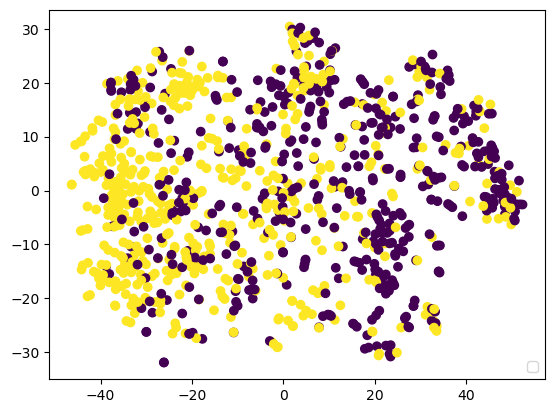

After Oversampling
Final_Ytrain
 1.0    523
0.0    498
dtype: int64
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Training Accuracy: 0.9285014691478942
Training MCC Score: 0.857045822455292
Training F1 Score: 0.9284792398550259
Training AUC VALUE: 0.9817606947867953
Training kappa Score: 0.8569652051592549
Training Precision: 0.936046511627907
Training Recall: 0.9235181644359465
Training Sensitivity: 0.9235181644359465
Training Specificity: 0.9337349397590361
Training CCR: 0.9285014691478942
Training PPV: 0.936046511627907


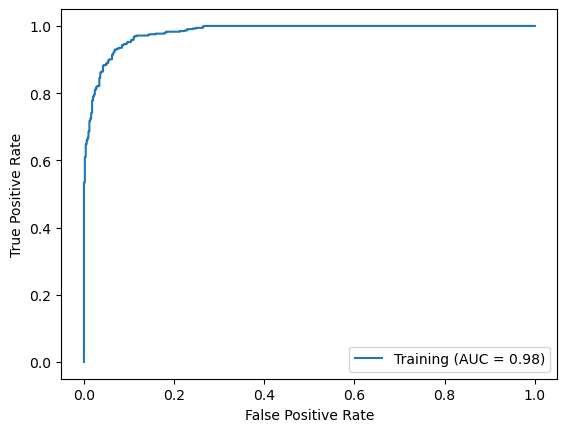

Testing Accuracy: 0.6906906906906907
Testing MCC Score: 0.38196168773449035
Testing F1 Score: 0.6895709075111549
Testing AUC VALUE: 0.729610446454625
Testing kappa Score: 0.38040356233177375
Testing Precision: 0.7396449704142012
Testing Recall: 0.6793478260869565
Testing Sensitivity: 0.6793478260869565
Testing Specificity: 0.7046979865771812
Testing CCR: 0.6906906906906907
Testing PPV: 0.7396449704142012


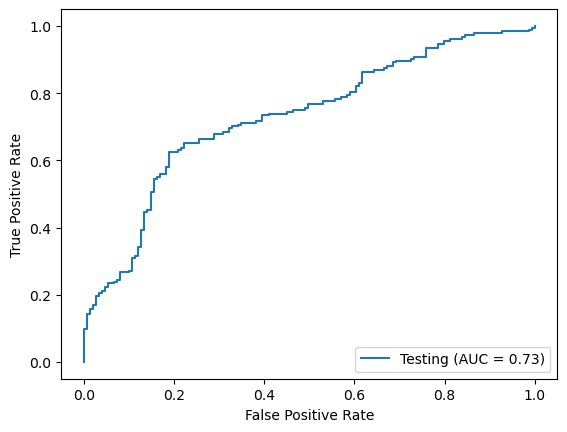

Fold # 1 Random Seed: 859
Before filteration
Train shape
 (996, 3200) 
Test shape
 (333, 3200)


KeyboardInterrupt: 

In [36]:
Train_Fold_outs=[]
Test_Fold_outs=[]
Best_params=[]
features = []
models=[]

#this chunk runs 20 iterations of the 5-Cross Validation of the pre-defined grid for the model
for i in range(20):
    #print('Fold #',i)   
    seed = random.randint(0, 1000)
    print('Fold #', i, "Random Seed:", seed)
    
    # Split Data
    X_train, X_test,y_train,y_test = train_test_split(Train,Train["status"] ,test_size=0.25, shuffle = True, random_state=seed)
    
    #Drop smiles,status from training,testing data
    x_train = X_train.drop(['status','smiles'], axis=1)
    x_test = X_test.drop(['status','smiles'], axis=1)

    #Feature selection
    x_train_filtered,x_test_filtered,y_train_filtered,y_test_filtered,selected_features = Boruta_Filteration(x_train,y_train,x_test,y_test)
    features.append(selected_features)
    
    y_train_filtered = pd.Series(y_train_filtered)

    print('Before Oversampling\ny_train_filtered\n',y_train_filtered.value_counts())
    #Oversampling
    Final_Xtrain,Final_Ytrain = Smote(x_train_filtered,y_train_filtered,0.5)
    print('After Oversampling\nFinal_Ytrain\n',Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)
    
    #Hyperparameter Tuning
    Parameters = HPTing_Model(Final_Xtrain,Final_Ytrain)
    
    #save best parameters
    Best_params.append(Parameters.best_estimator_.get_params())
    
    #build the tuned model
    #edit the parameters here according to your defined parameter space and model's grid
    rf = RandomForestClassifier(max_features=Parameters.best_estimator_.get_params()['max_features'],
                        max_depth=Parameters.best_estimator_.get_params()['max_depth'],
                        min_samples_split=Parameters.best_estimator_.get_params()['min_samples_split'],
                        min_samples_leaf=Parameters.best_estimator_.get_params()['min_samples_leaf'],
                        bootstrap=Parameters.best_estimator_.get_params()['bootstrap'],
                        n_estimators=Parameters.best_estimator_.get_params()['n_estimators'])

    
    #fit the built model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models.append(rf)

    #Training Predictions for the model
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)

    #Save training metrics
    Train_Fold_outs.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain,'Training'))

    #Testing Predictions for the model
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)

    #Save testing metrics
    Test_Fold_outs.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered,'Testing'))

In [71]:
#Analyse the testing metrics sorted by descending Testing Accuracy
pd.DataFrame.from_dict(Test_Fold_outs).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:
3,0.711712,0.424647,0.711397,0.773465,0.423543,0.729032,0.676647
5,0.711712,0.420207,0.710078,0.772526,0.420176,0.727778,0.735955
14,0.708709,0.416185,0.708035,0.774133,0.416117,0.715909,0.728324
2,0.711712,0.409627,0.704787,0.745670,0.409596,0.753927,0.746114
4,0.699700,0.397640,0.698719,0.753896,0.397525,0.724138,0.707865
15,0.699700,0.395995,0.697998,0.750816,0.395995,0.720670,0.720670
0,0.696697,0.392234,0.695808,0.733403,0.391885,0.726744,0.698324
9,0.693694,0.388634,0.693691,0.728008,0.387934,0.716049,0.674419
7,0.693694,0.384904,0.692225,0.770669,0.384652,0.701657,0.725714
19,0.690691,0.373535,0.686610,0.735009,0.373363,0.712766,0.732240


In [79]:
#View the best parameters
pd.DataFrame.from_dict(Best_params)

,bootstrap,ccp_alpha,class_weight,criterion,max_depth,max_features,max_leaf_nodes,max_samples,min_impurity_decrease,min_samples_leaf,min_samples_split,min_weight_fraction_leaf,n_estimators,n_jobs,oob_score,random_state,verbose,warm_start
0,True,0.0,None,gini,40.0,sqrt,None,None,0.0,2,22,0.0,45,None,False,None,0,False
1,True,0.0,None,gini,80.0,0.5,None,None,0.0,2,26,0.0,89,None,False,None,0,False
2,True,0.0,None,gini,NaN,sqrt,None,None,0.0,5,10,0.0,56,None,False,None,0,False
3,False,0.0,None,gini,90.0,log2,None,None,0.0,5,8,0.0,100,None,False,None,0,False
4,False,0.0,None,gini,30.0,log2,None,None,0.0,2,18,0.0,78,None,False,None,0,False
5,True,0.0,None,gini,20.0,log2,None,None,0.0,8,16,0.0,23,None,False,None,0,False
6,True,0.0,None,gini,50.0,None,None,None,0.0,1,10,0.0,67,None,False,None,0,False
7,False,0.0,None,gini,30.0,sqrt,None,None,0.0,6,12,0.0,45,None,False,None,0,False
8,True,0.0,None,gini,50.0,sqrt,None,None,0.0,4,10,0.0,45,None,False,None,0,False
9,False,0.0,None,gini,60.0,log2,None,None,0.0,1,15,0.0,89,None,False,None,0,False


In [81]:
#View length of the features selected for the top performing/most stable (selected) model (1st here)
len(features[3])

46

In [91]:
#Save the feature names
pd.DataFrame(features[3]).to_csv('AID_1189_features.csv',index=False)

In [92]:
#save the best parameters of the chosen model
with open('AID_1189_best_params_RF.csv', 'w') as f:  # You will need 'wb' mode in Python 2.x
    w = csv.DictWriter(f, Best_params[3].keys())
    w.writeheader()
    w.writerow(Best_params[3])

In [ ]:
"""
#Randomly split the data into testing and validation for each fold
def Test_valid_split(Set3,frac,seed):
    Fraction=frac
    Test=Set3[Set3['status']==1].sample(frac = Fraction,random_state=1).append(Set3[Set3['status']==0].sample(frac = Fraction,random_state=seed))
    Valid_index=[item for item in list(Set3.index) if item not in list(Test.index)]
    Valid=Set3.T[Valid_index].T
    print('Test set size:',len(Test),'\nValid set size:',len(Valid))
    return Test,Valid
"""

In [37]:
def Test_valid_split(Set3, frac, seed):
    Fraction = frac
    Test_1 = Set3[Set3['status'] == 1].sample(frac=Fraction, random_state=1)
    Test_0 = Set3[Set3['status'] == 0].sample(frac=Fraction, random_state=seed)
    
    # 使用 pd.concat 代替 append
    Test = pd.concat([Test_1, Test_0])
    
    Valid_index = [item for item in list(Set3.index) if item not in list(Test.index)]
    Valid = Set3.T[Valid_index].T
    print('Test set size:', len(Test), '\nValid set size:', len(Valid))
    
    return Test, Valid

In [39]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv('AID_1189_features.csv')

# 假设第一列名为 'Features'
f_list = df['Features'].tolist()

# 输出 f_list 确认结果
print(f_list)

['B1_27', 'B2_60', 'B2_123', 'B3_41', 'C1_0', 'C1_18', 'C1_41', 'C1_57', 'C1_95', 'C1_102', 'C1_103', 'C1_121', 'D1_20', 'D1_46', 'D1_64', 'D1_78', 'D1_97', 'D1_105', 'D2_104', 'D3_112', 'D5_102', 'D5_120', 'E1_9', 'E4_5', 'E4_6', 'E4_15', 'E4_17', 'E4_22', 'E4_37', 'E4_60', 'E4_70', 'E4_74', 'E4_79', 'E4_85', 'E4_90', 'E4_93', 'E4_106', 'E4_111', 'E4_112', 'E4_115', 'E4_117', 'E4_118', 'E4_120', 'E4_122', 'E5_37', 'E5_53']


{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 90.0, 'max_features': 'log2', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 5, 'min_samples_split': 8, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}
Fold # 0


2024-11-04 19:45:54,612:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:45:54,614:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:45:54,614:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


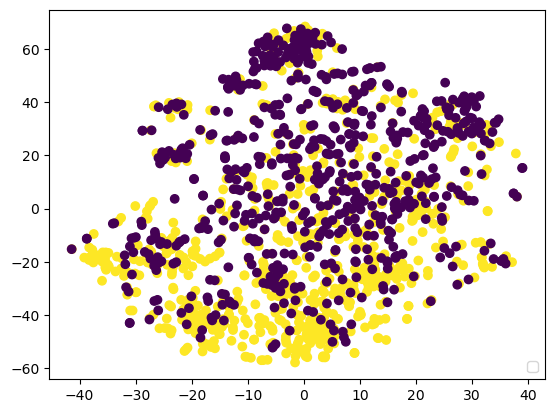

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9963530269876003
Training MCC Score: 0.9927269910114982
Training F1 Score: 0.996350223112911
Training AUC VALUE: 0.9999637872565226
Training kappa Score: 0.992700543386245
Training Precision: 1.0
Training Recall: 0.9929278642149929


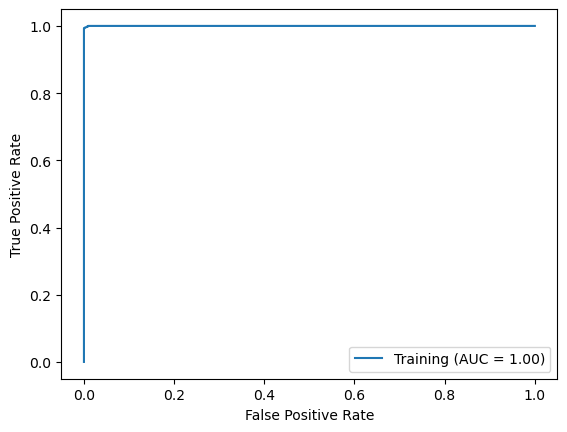

Testing Accuracy: 0.7162162162162162
Testing MCC Score: 0.4281123971376602
Testing F1 Score: 0.7128603104212861
Testing AUC VALUE: 0.7429829389102917
Testing kappa Score: 0.4266740453790814
Testing Precision: 0.7176470588235294
Testing Recall: 0.7721518987341772


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


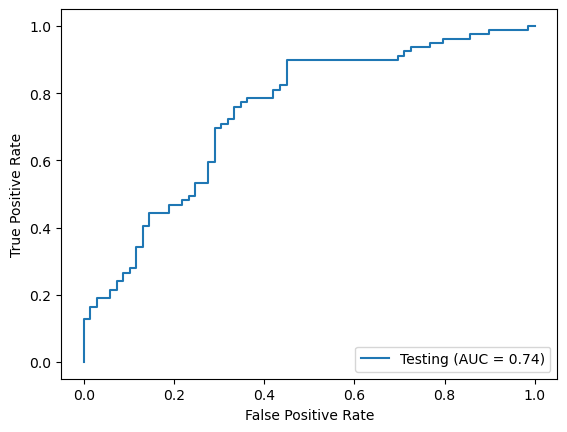

Fold # 1
Test set size: 1329 
Valid set size: 148


2024-11-04 19:45:58,594:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:45:58,595:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:45:58,596:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


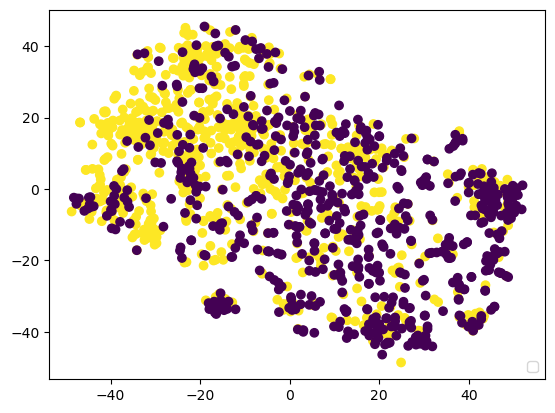

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9970824215900802
Training MCC Score: 0.9941590974932261
Training F1 Score: 0.9970795487466131
Training AUC VALUE: 0.9999659174179035
Training kappa Score: 0.9941590974932261
Training Precision: 0.9971711456859972
Training Recall: 0.9971711456859972


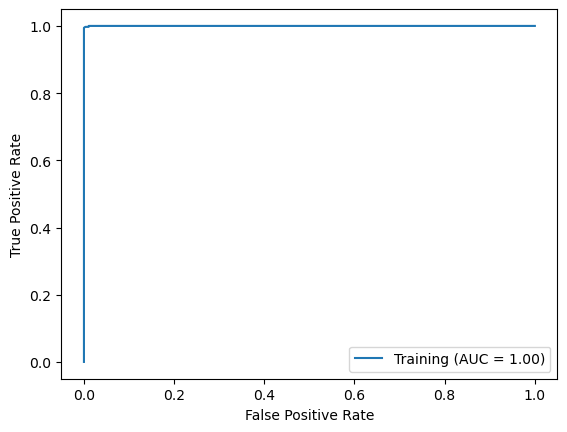

Testing Accuracy: 0.668918918918919
Testing MCC Score: 0.3332434253775086
Testing F1 Score: 0.6663446054750404
Testing AUC VALUE: 0.7424325811777657
Testing kappa Score: 0.33296541574687266
Testing Precision: 0.6829268292682927
Testing Recall: 0.7088607594936709


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


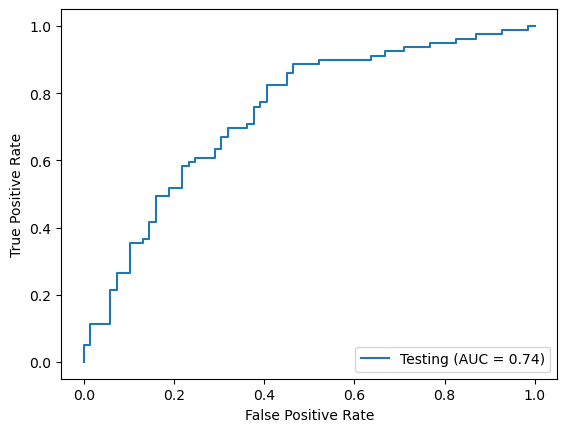

Fold # 2


2024-11-04 19:46:02,758:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:02,759:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:02,760:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


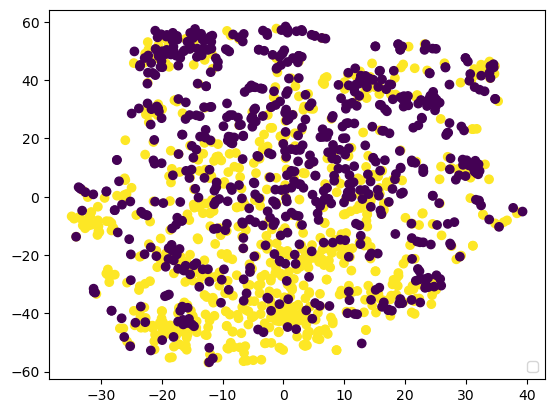

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9970824215900802
Training MCC Score: 0.9941590974932261
Training F1 Score: 0.9970795487466131
Training AUC VALUE: 0.9999829587089518
Training kappa Score: 0.9941590974932261
Training Precision: 0.9971711456859972
Training Recall: 0.9971711456859972


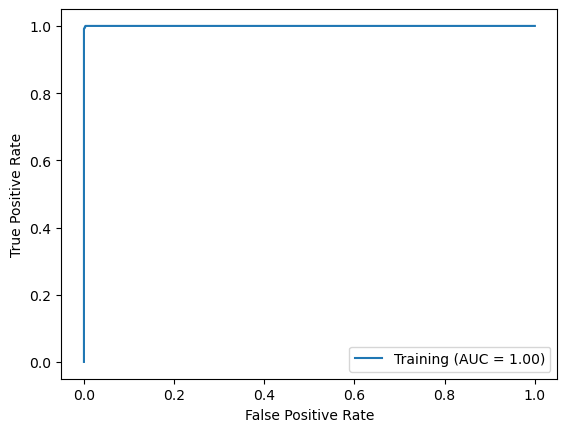

Testing Accuracy: 0.7567567567567568
Testing MCC Score: 0.5138214848902163
Testing F1 Score: 0.7563563197366014
Testing AUC VALUE: 0.8482847184002935
Testing kappa Score: 0.5130689087918114
Testing Precision: 0.7866666666666666
Testing Recall: 0.7468354430379747


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


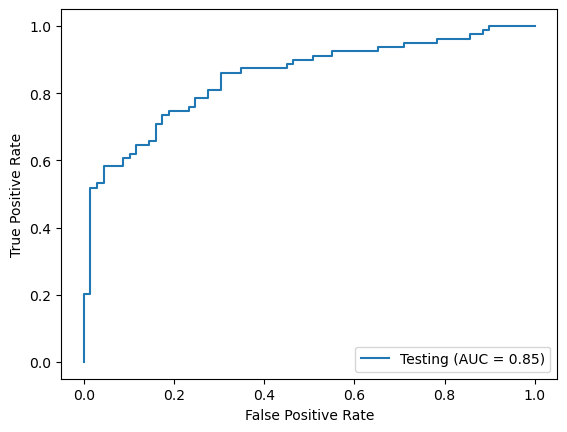

Fold # 3


2024-11-04 19:46:07,040:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:07,041:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:07,042:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


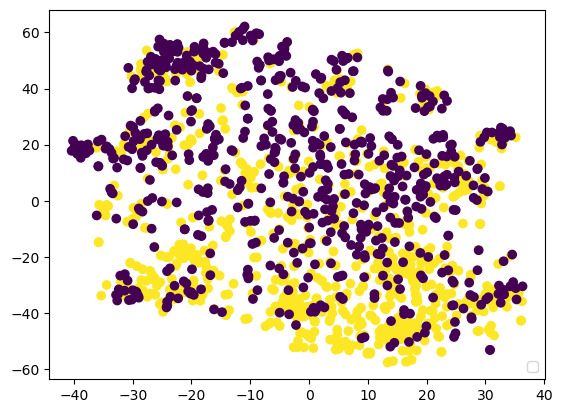

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9970824215900802
Training MCC Score: 0.9941590974932261
Training F1 Score: 0.9970795487466131
Training AUC VALUE: 0.9999701777406657
Training kappa Score: 0.9941590974932261
Training Precision: 0.9971711456859972
Training Recall: 0.9971711456859972


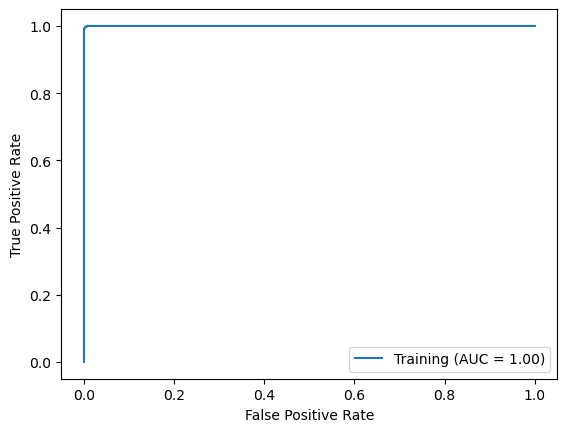

Testing Accuracy: 0.7162162162162162
Testing MCC Score: 0.42894018720357274
Testing F1 Score: 0.7143382352941177
Testing AUC VALUE: 0.7881122729774354
Testing kappa Score: 0.4287814739937512
Testing Precision: 0.7283950617283951
Testing Recall: 0.7468354430379747


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


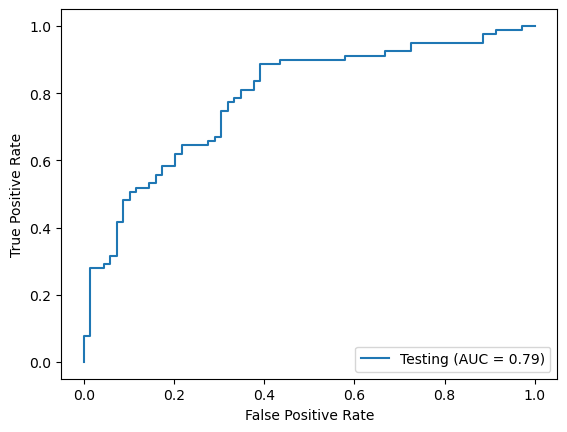

Fold # 4


2024-11-04 19:46:11,217:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:11,218:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:11,219:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


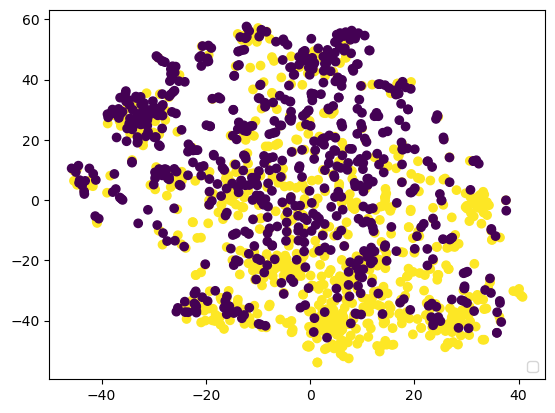

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9963530269876003
Training MCC Score: 0.9926995959144991
Training F1 Score: 0.9963492667911094
Training AUC VALUE: 0.9999595269337606
Training kappa Score: 0.9926985374707222
Training Precision: 0.9957627118644068
Training Recall: 0.9971711456859972


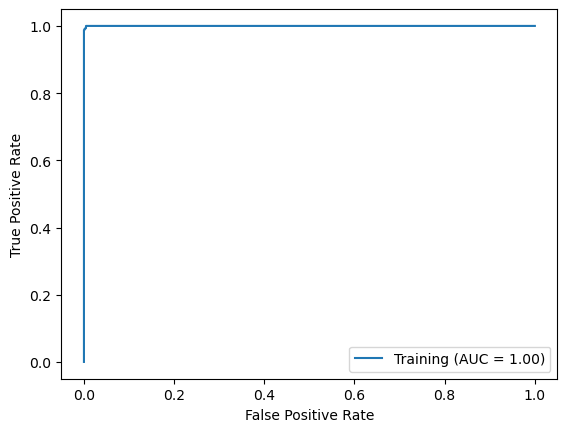

Testing Accuracy: 0.7364864864864865
Testing MCC Score: 0.46948659376389335
Testing F1 Score: 0.7344375431331953
Testing AUC VALUE: 0.7945331131902402
Testing kappa Score: 0.4690949227373068
Testing Precision: 0.7439024390243902
Testing Recall: 0.7721518987341772


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


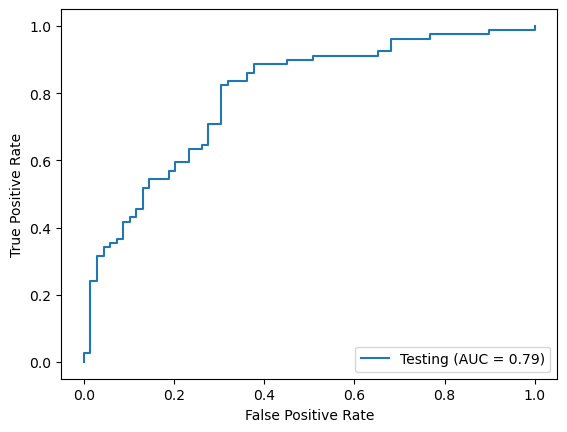

Fold # 5


2024-11-04 19:46:15,448:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:15,449:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:15,450:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


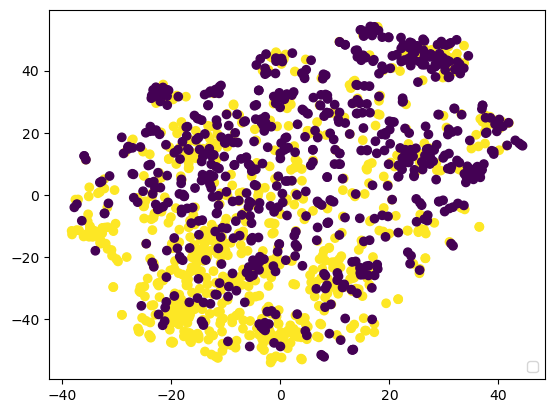

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9963530269876003
Training MCC Score: 0.9927002644823216
Training F1 Score: 0.9963496011719617
Training AUC VALUE: 0.9999808285475708
Training kappa Score: 0.9926992062317147
Training Precision: 0.9971671388101983
Training Recall: 0.9957567185289957


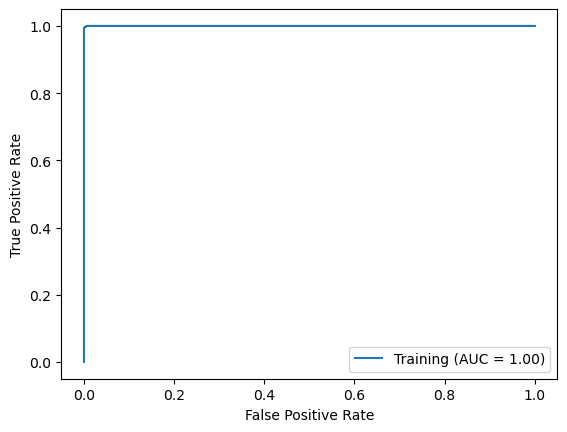

Testing Accuracy: 0.7094594594594594
Testing MCC Score: 0.41498932640933944
Testing F1 Score: 0.7072003680699332
Testing AUC VALUE: 0.7655476059438636
Testing kappa Score: 0.4146431199411331
Testing Precision: 0.7195121951219512
Testing Recall: 0.7468354430379747


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


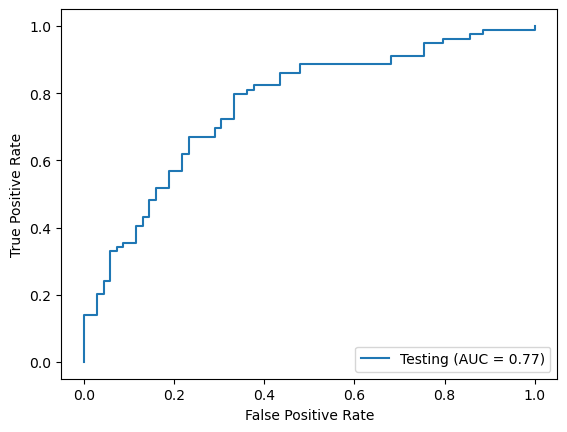

Fold # 6


2024-11-04 19:46:19,626:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:19,628:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:19,629:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


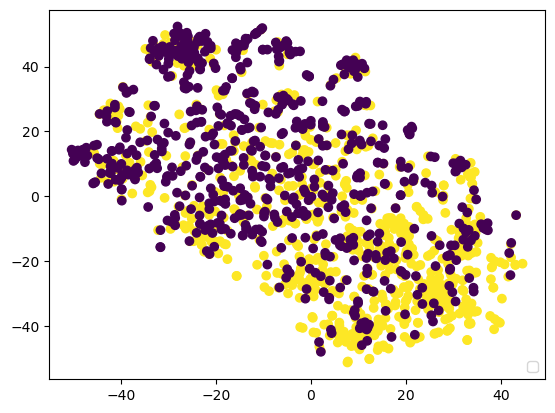

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9956236323851203
Training MCC Score: 0.9912436750905098
Training F1 Score: 0.9956197150099044
Training AUC VALUE: 0.9999723079020467
Training kappa Score: 0.9912394486795274
Training Precision: 0.9971631205673759
Training Recall: 0.9943422913719944


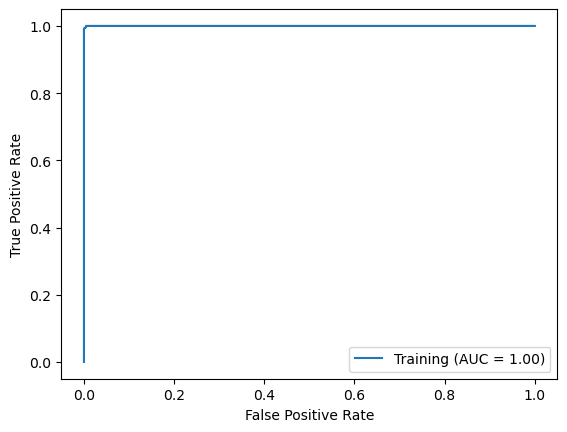

Testing Accuracy: 0.668918918918919
Testing MCC Score: 0.33422108682525037
Testing F1 Score: 0.6670798328972134
Testing AUC VALUE: 0.7840763162722436
Testing kappa Score: 0.33419023136246784
Testing Precision: 0.6875
Testing Recall: 0.6962025316455697


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


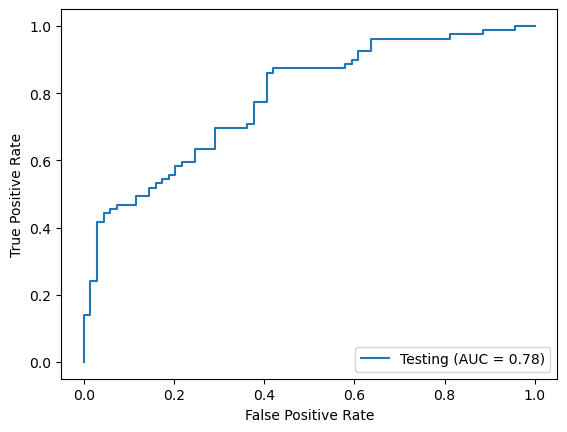

Fold # 7


2024-11-04 19:46:23,794:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:23,795:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:23,796:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


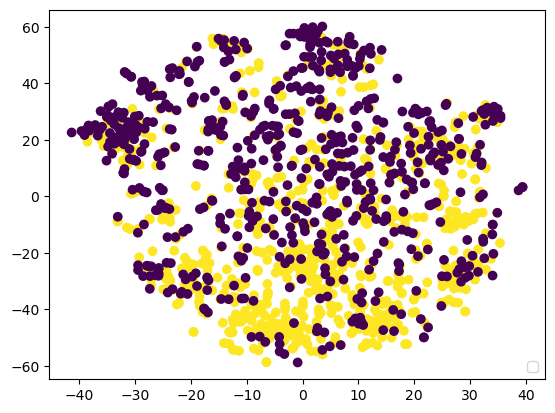

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9941648431801605
Training MCC Score: 0.9883234788660448
Training F1 Score: 0.9941596200132059
Training AUC VALUE: 0.9999446158040933
Training kappa Score: 0.9883192649060365
Training Precision: 0.9957446808510638
Training Recall: 0.9929278642149929


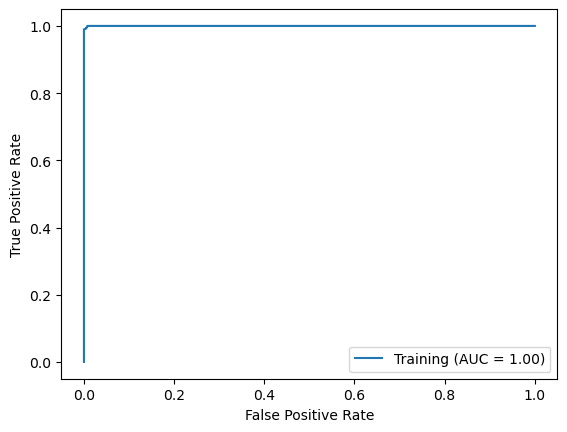

Testing Accuracy: 0.7162162162162162
Testing MCC Score: 0.42894018720357274
Testing F1 Score: 0.7143382352941177
Testing AUC VALUE: 0.7558246193359017
Testing kappa Score: 0.4287814739937512
Testing Precision: 0.7283950617283951
Testing Recall: 0.7468354430379747


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


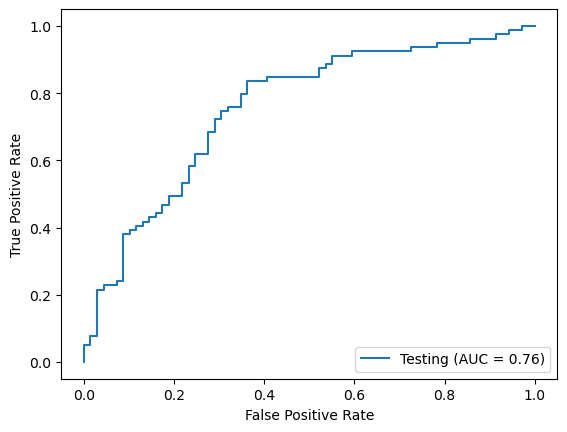

Fold # 8


2024-11-04 19:46:27,979:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:27,980:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:27,981:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


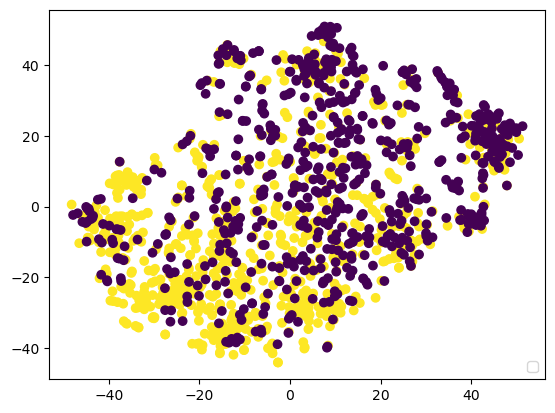

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9963530269876003
Training MCC Score: 0.9927002644823216
Training F1 Score: 0.9963496011719617
Training AUC VALUE: 0.9999616570951414
Training kappa Score: 0.9926992062317147
Training Precision: 0.9971671388101983
Training Recall: 0.9957567185289957


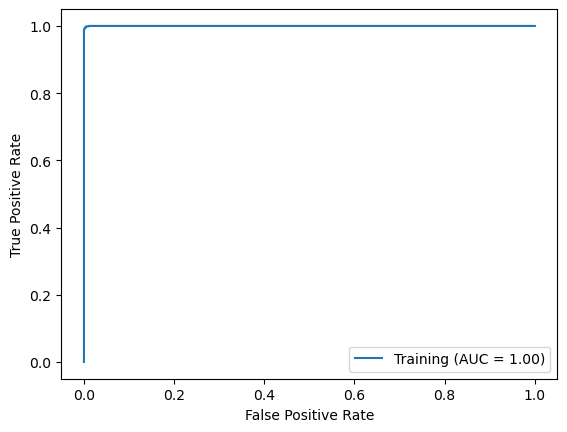

Testing Accuracy: 0.7432432432432432
Testing MCC Score: 0.4833620883661349
Testing F1 Score: 0.7415441176470587
Testing AUC VALUE: 0.7901302513300311
Testing kappa Score: 0.48318323837529864
Testing Precision: 0.7530864197530864
Testing Recall: 0.7721518987341772


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


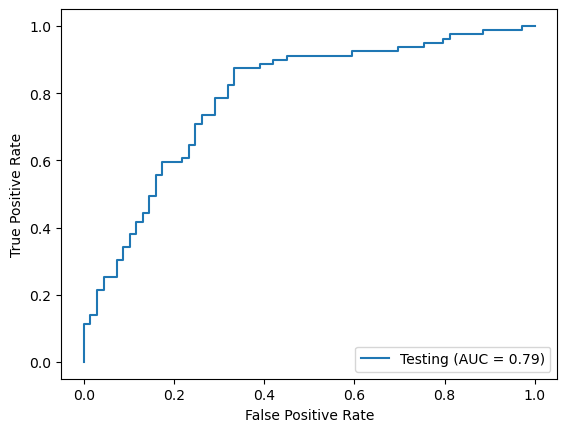

Fold # 9


2024-11-04 19:46:32,064:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:32,065:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:32,066:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


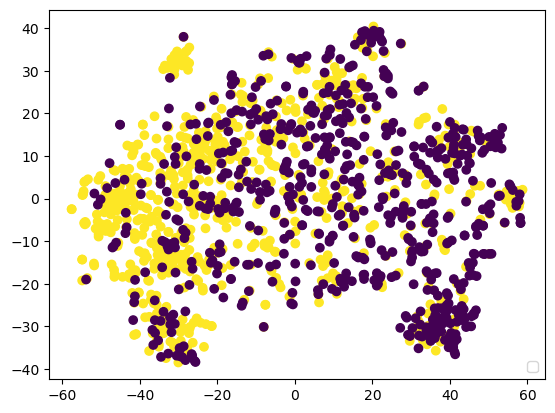

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9985412107950401
Training MCC Score: 0.9970795487466131
Training F1 Score: 0.9985397743733064
Training AUC VALUE: 0.9999893491930949
Training kappa Score: 0.9970795487466131
Training Precision: 0.9985855728429985
Training Recall: 0.9985855728429985


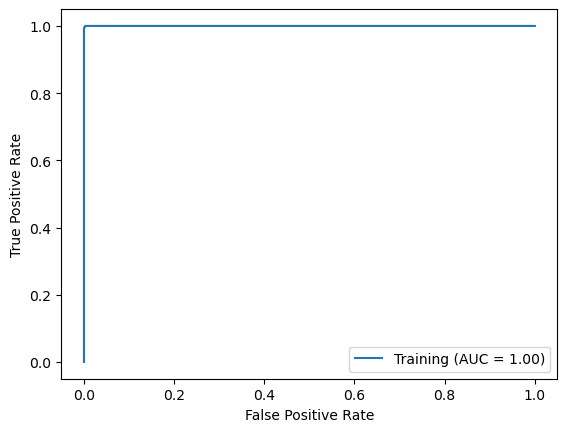

Testing Accuracy: 0.7972972972972973
Testing MCC Score: 0.596926206707159
Testing F1 Score: 0.7971491228070176
Testing AUC VALUE: 0.8304898183819484
Testing kappa Score: 0.5949644225506294
Testing Precision: 0.8356164383561644
Testing Recall: 0.7721518987341772


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


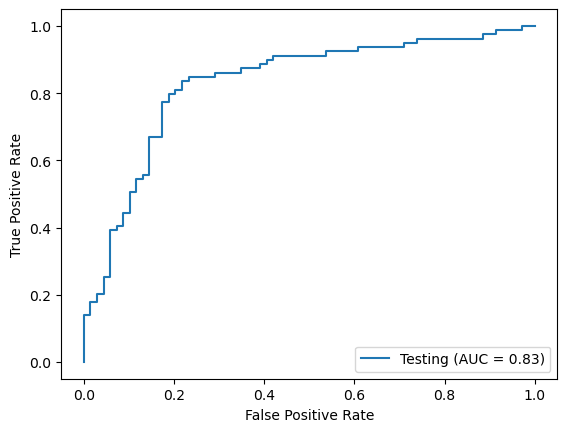

Fold # 10


2024-11-04 19:46:36,456:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:36,458:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:36,458:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


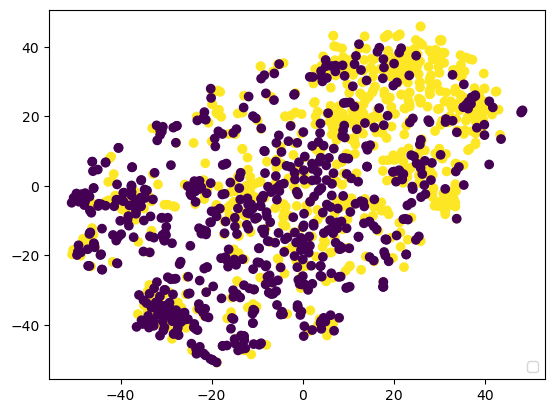

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9963530269876003
Training MCC Score: 0.9927093975094137
Training F1 Score: 0.9963499199431749
Training AUC VALUE: 0.9999680475792847
Training kappa Score: 0.9926998748702112
Training Precision: 0.9985795454545454
Training Recall: 0.9943422913719944


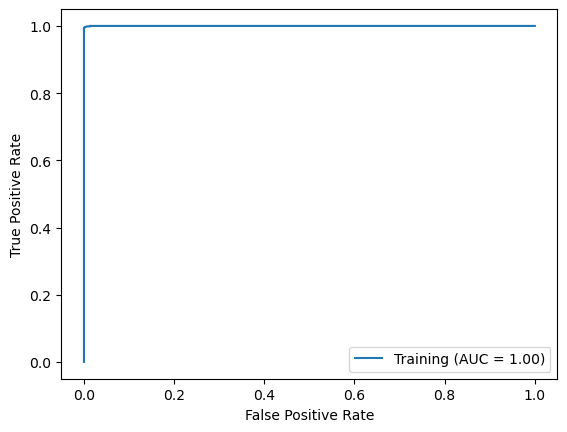

Testing Accuracy: 0.7364864864864865
Testing MCC Score: 0.4692857422827683
Testing F1 Score: 0.7329632199861207
Testing AUC VALUE: 0.7649972482113374
Testing kappa Score: 0.46713441654357457
Testing Precision: 0.7325581395348837
Testing Recall: 0.7974683544303798


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


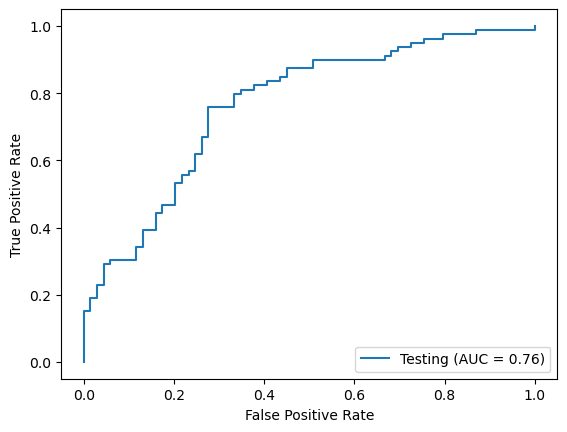

Fold # 11


2024-11-04 19:46:40,635:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:40,636:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:40,637:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


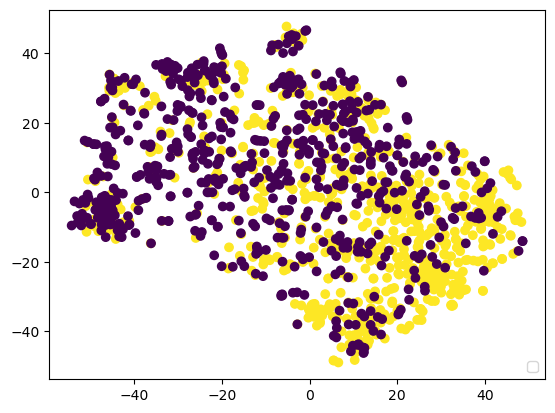

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9970824215900802
Training MCC Score: 0.9941590974932261
Training F1 Score: 0.9970795487466131
Training AUC VALUE: 0.9999701777406657
Training kappa Score: 0.9941590974932261
Training Precision: 0.9971711456859972
Training Recall: 0.9971711456859972


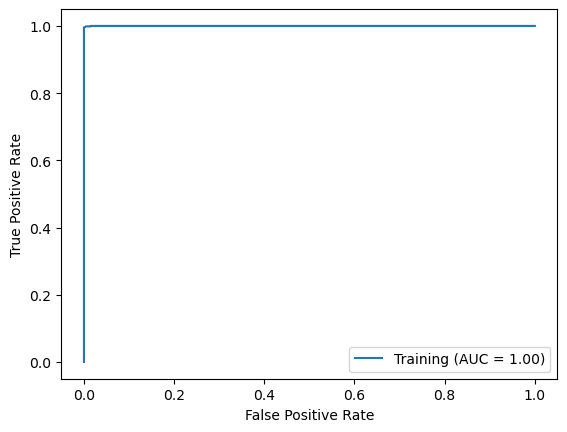

Testing Accuracy: 0.7567567567567568
Testing MCC Score: 0.5102922087801682
Testing F1 Score: 0.753880266075388
Testing AUC VALUE: 0.7914144193725923
Testing kappa Score: 0.5085777531820697
Testing Precision: 0.7529411764705882
Testing Recall: 0.810126582278481


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


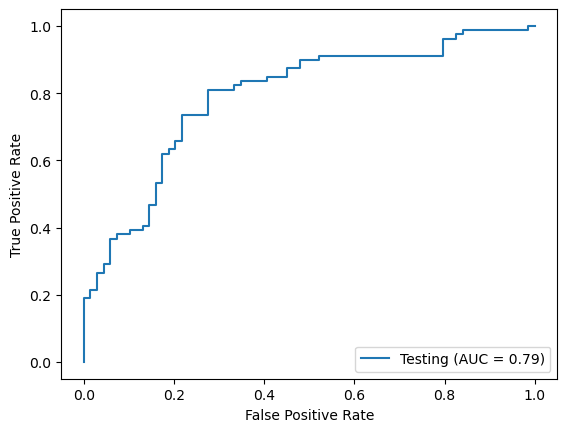

Fold # 12


2024-11-04 19:46:44,841:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:44,842:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:44,843:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


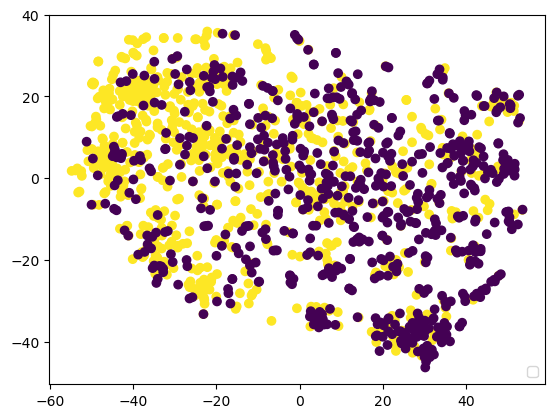

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9963530269876003
Training MCC Score: 0.9927093975094137
Training F1 Score: 0.9963499199431749
Training AUC VALUE: 0.9999701777406655
Training kappa Score: 0.9926998748702112
Training Precision: 0.9985795454545454
Training Recall: 0.9943422913719944


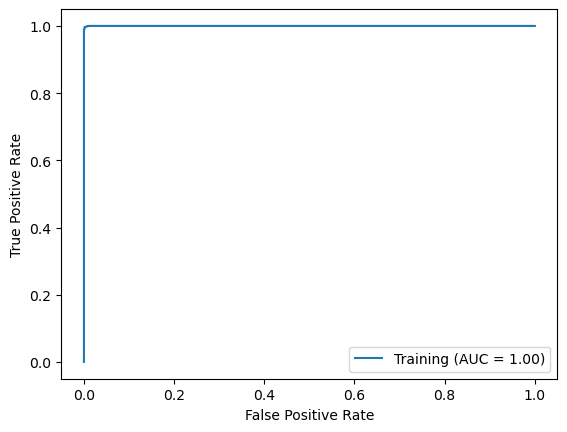

Testing Accuracy: 0.7162162162162162
Testing MCC Score: 0.4298293891029169
Testing F1 Score: 0.7149146945514584
Testing AUC VALUE: 0.769767015226564
Testing kappa Score: 0.4298293891029169
Testing Precision: 0.7341772151898734
Testing Recall: 0.7341772151898734


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


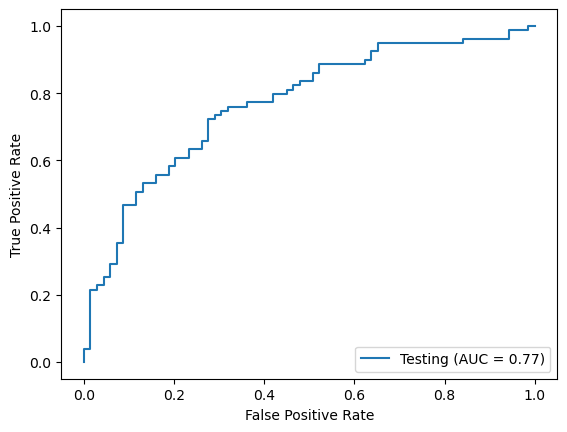

Fold # 13
Test set size: 1329 
Valid set size: 148


2024-11-04 19:46:48,939:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:48,940:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:48,941:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


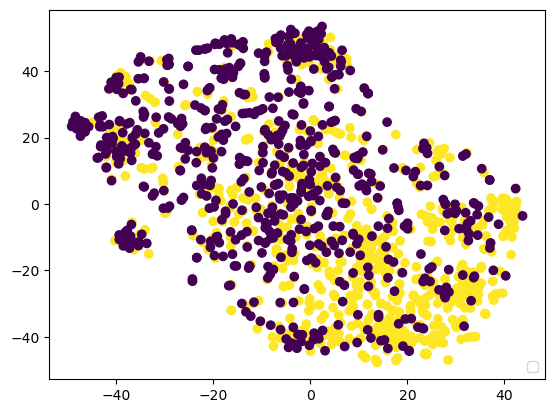

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9978118161925602
Training MCC Score: 0.9956294755723966
Training F1 Score: 0.9978099519659049
Training AUC VALUE: 0.9999914793544759
Training kappa Score: 0.9956199249221267
Training Precision: 1.0
Training Recall: 0.9957567185289957


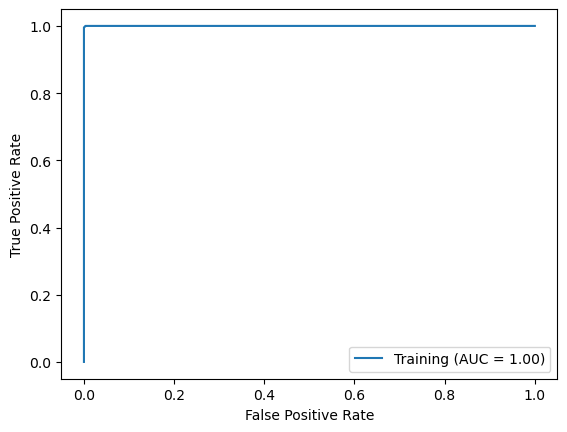

Testing Accuracy: 0.7297297297297297
Testing MCC Score: 0.45565792685268364
Testing F1 Score: 0.7272894785332596
Testing AUC VALUE: 0.773619519354247
Testing kappa Score: 0.45498066654391456
Testing Precision: 0.7349397590361446
Testing Recall: 0.7721518987341772


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


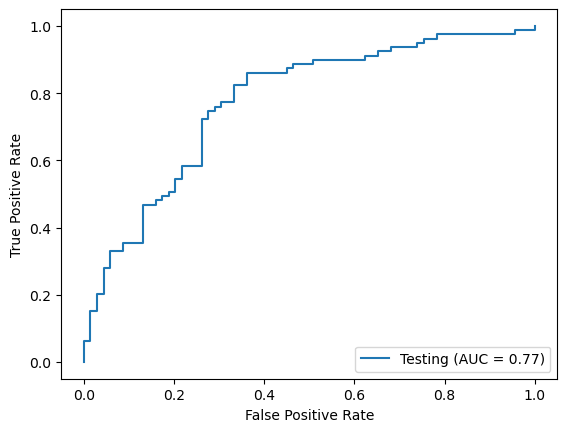

Fold # 14


2024-11-04 19:46:53,125:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:53,126:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:53,127:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


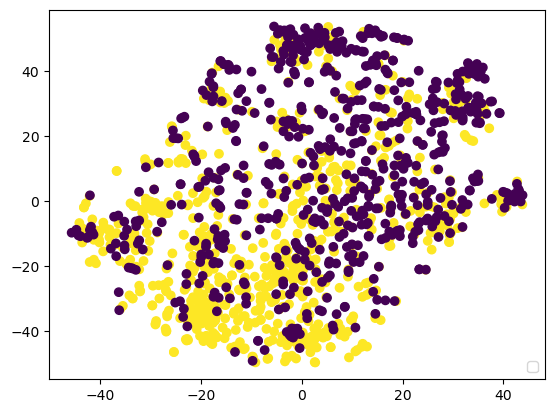

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9978118161925602
Training MCC Score: 0.9956201840402221
Training F1 Score: 0.9978095600746655
Training AUC VALUE: 0.9999797634668802
Training kappa Score: 0.9956191224824333
Training Precision: 0.9971751412429378
Training Recall: 0.9985855728429985


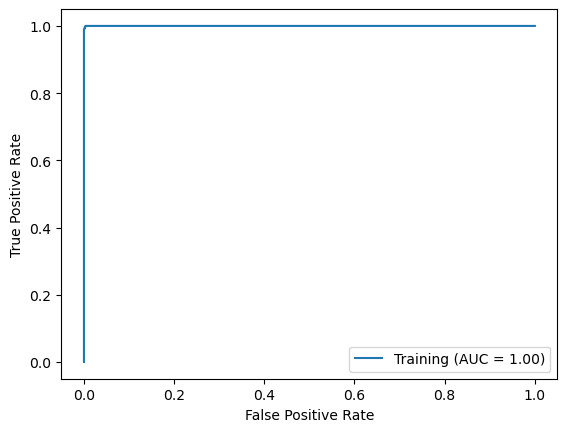

Testing Accuracy: 0.75
Testing MCC Score: 0.49821298224657545
Testing F1 Score: 0.7490720799156854
Testing AUC VALUE: 0.8110438451660247
Testing kappa Score: 0.49816715542521994
Testing Precision: 0.7692307692307693
Testing Recall: 0.759493670886076


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


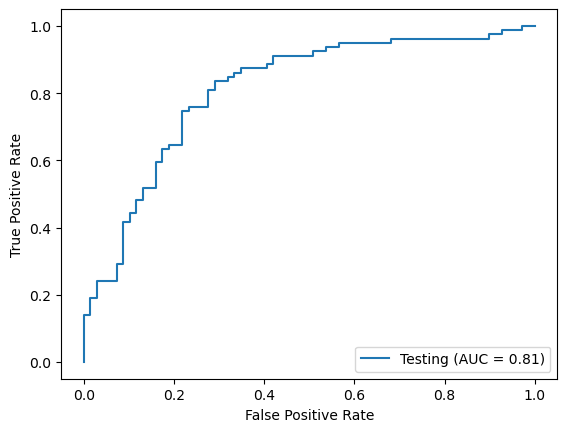

Fold # 15


2024-11-04 19:46:57,268:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:46:57,269:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:46:57,270:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


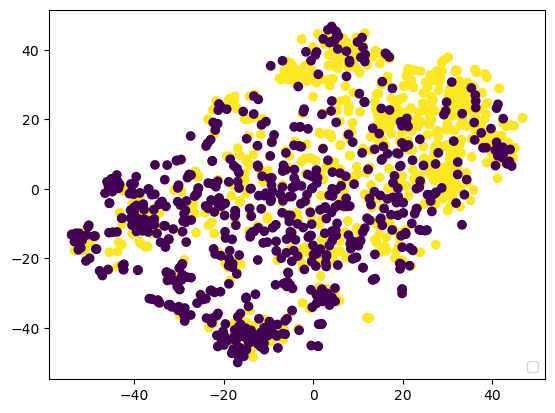

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9948942377826404
Training MCC Score: 0.9897790077887761
Training F1 Score: 0.9948889735075532
Training AUC VALUE: 0.9999659174179036
Training kappa Score: 0.9897779524590111
Training Precision: 0.9943502824858758
Training Recall: 0.9957567185289957


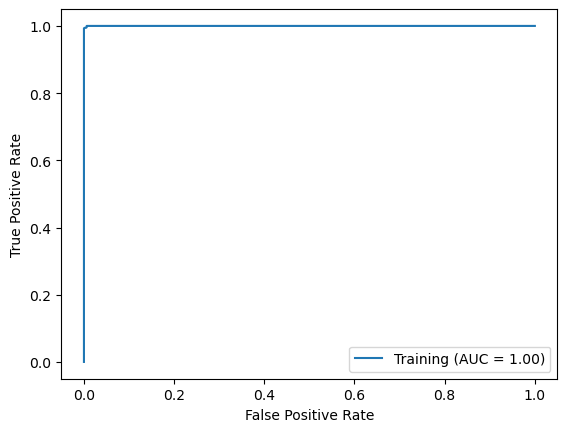

Testing Accuracy: 0.6621621621621622
Testing MCC Score: 0.3185393149476495
Testing F1 Score: 0.6581670362158167
Testing AUC VALUE: 0.7279398275545771
Testing kappa Score: 0.31746910164176356
Testing Precision: 0.6705882352941176
Testing Recall: 0.7215189873417721


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


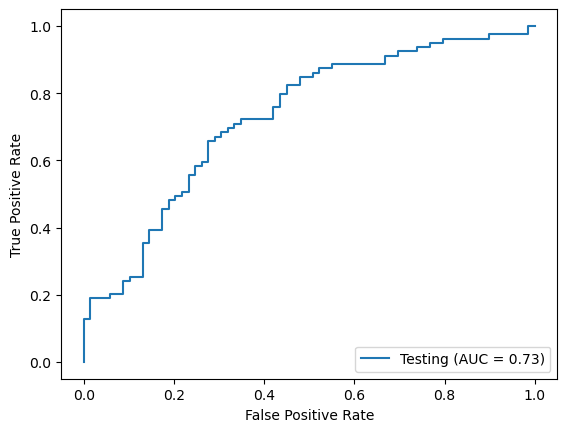

Fold # 16


2024-11-04 19:47:01,504:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:47:01,505:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:47:01,506:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


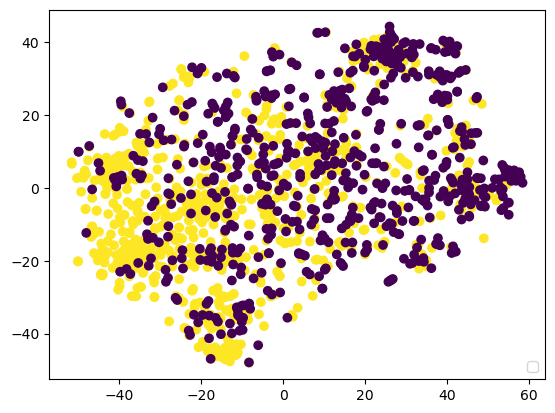

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9978118161925602
Training MCC Score: 0.995620585102792
Training F1 Score: 0.9978097607031771
Training AUC VALUE: 0.9999861539510232
Training kappa Score: 0.9956195237390288
Training Precision: 0.9985835694050992
Training Recall: 0.9971711456859972


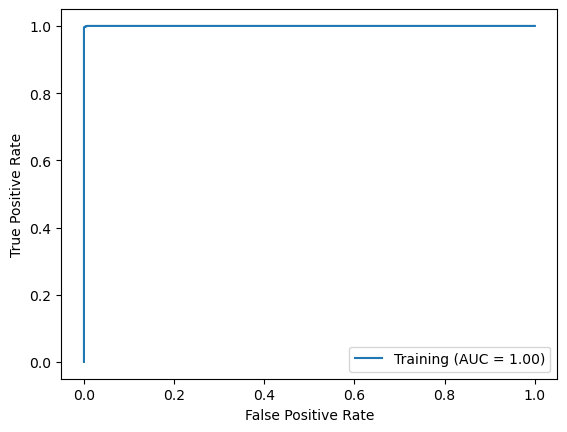

Testing Accuracy: 0.7094594594594594
Testing MCC Score: 0.4157563409738279
Testing F1 Score: 0.7078455676444934
Testing AUC VALUE: 0.7587598605760412
Testing kappa Score: 0.4157179581344106
Testing Precision: 0.725
Testing Recall: 0.7341772151898734


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


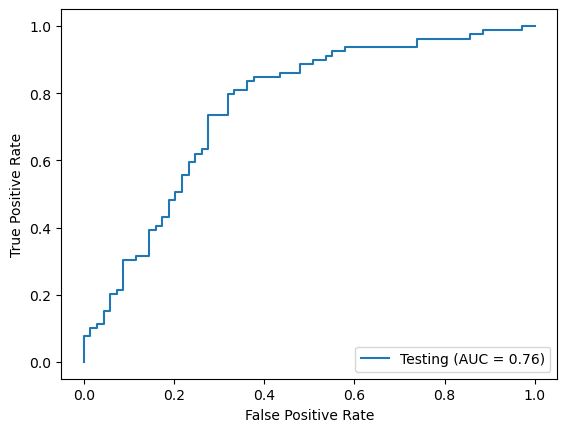

Fold # 17


2024-11-04 19:47:05,680:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:47:05,681:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:47:05,681:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


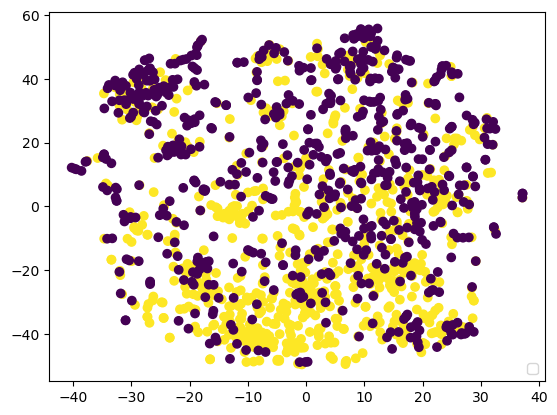

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9978118161925602
Training MCC Score: 0.9956201840402221
Training F1 Score: 0.9978095600746655
Training AUC VALUE: 0.9999744380634277
Training kappa Score: 0.9956191224824333
Training Precision: 0.9971751412429378
Training Recall: 0.9985855728429985


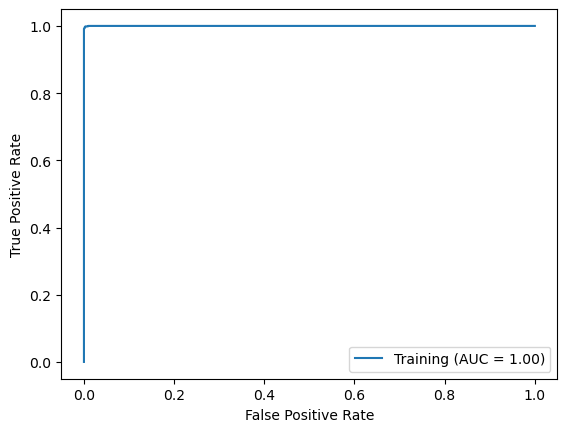

Testing Accuracy: 0.75
Testing MCC Score: 0.499497398447712
Testing F1 Score: 0.7494394875314574
Testing AUC VALUE: 0.7912309667950835
Testing kappa Score: 0.49908525429930484
Testing Precision: 0.7763157894736842
Testing Recall: 0.7468354430379747


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


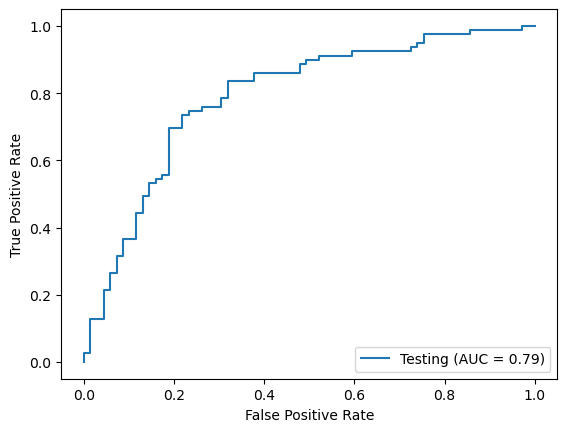

Fold # 18


2024-11-04 19:47:09,922:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:47:09,923:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:47:09,924:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


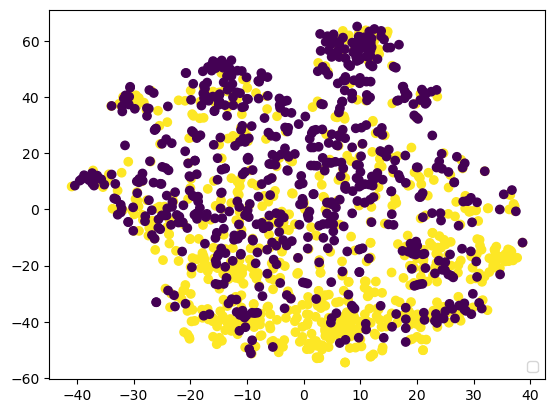

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9978118161925602
Training MCC Score: 0.995620585102792
Training F1 Score: 0.9978097607031771
Training AUC VALUE: 0.9999850888703329
Training kappa Score: 0.9956195237390288
Training Precision: 0.9985835694050992
Training Recall: 0.9971711456859972


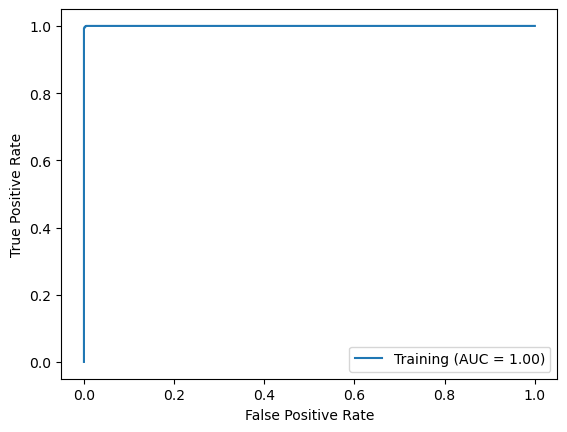

Testing Accuracy: 0.7432432432432432
Testing MCC Score: 0.4867300777780852
Testing F1 Score: 0.7428205597219681
Testing AUC VALUE: 0.8156301596037424
Testing kappa Score: 0.48601718150246753
Testing Precision: 0.7733333333333333
Testing Recall: 0.7341772151898734


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


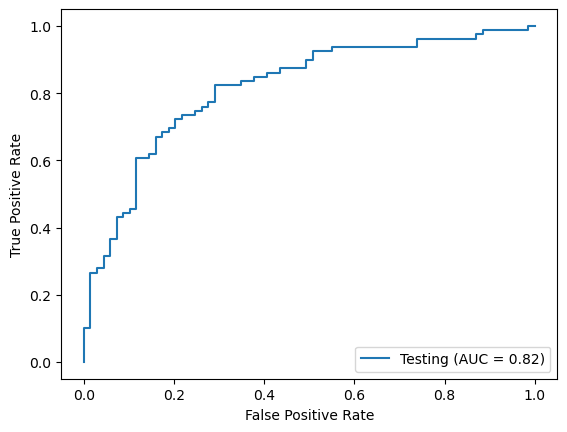

Fold # 19


2024-11-04 19:47:14,136:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:47:14,137:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:47:14,138:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Test set size: 1329 
Valid set size: 148
(1329, 46)
status
1.0    707
0.0    622
Name: count, dtype: int64


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


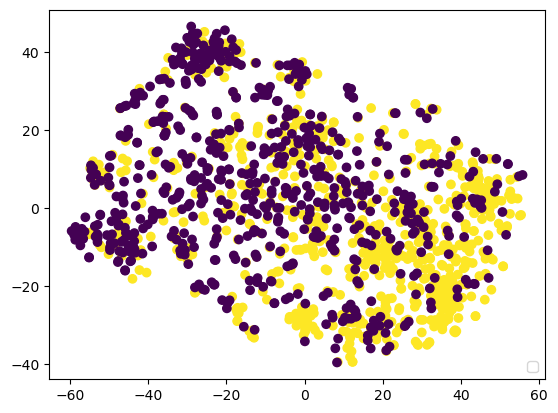

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9963530269876003
Training MCC Score: 0.9927093975094137
Training F1 Score: 0.9963499199431749
Training AUC VALUE: 0.9999680475792846
Training kappa Score: 0.9926998748702112
Training Precision: 0.9985795454545454
Training Recall: 0.9943422913719944


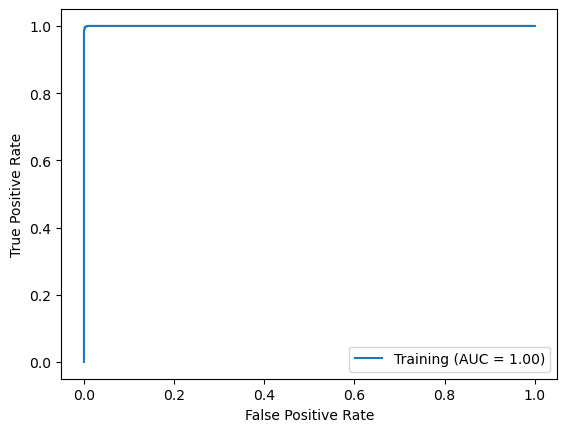

Testing Accuracy: 0.7094594594594594
Testing MCC Score: 0.4157563409738279
Testing F1 Score: 0.7078455676444934
Testing AUC VALUE: 0.7754540451293341
Testing kappa Score: 0.4157179581344106
Testing Precision: 0.725
Testing Recall: 0.7341772151898734


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


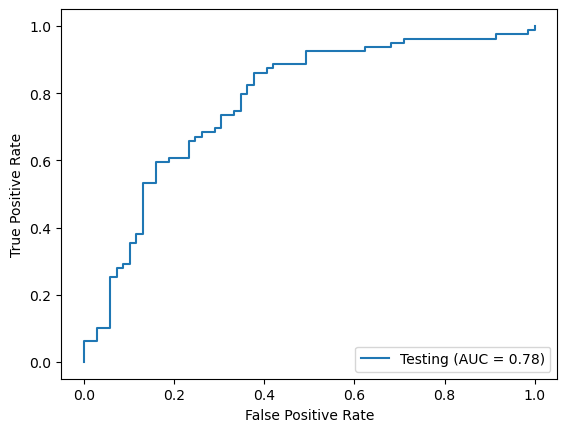

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob[:, 1])\n    all_labels.extend(Final_Ytrain.astype('int'))\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob[:, 1])\n    all_labels.extend(y_test_filtered.astype('int'))\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [89]:
''' 
#f_list=features[1] #feature list of the selected (hyperparameter tuned) model
Train_Fold_outs_1=[]
Test_Fold_outs_1=[]
models_1=[]

# 用于存储训练和测试集的预测结果和标签
total_metrics= []


Parameters = pd.DataFrame.from_dict(Best_params).iloc[3].to_dict()
print(Parameters)
for i in range(20):
    print('Fold #',i)
    
    #Train-test split randomly
    Trn,Tst = Test_valid_split(Data,0.9,i)
    Train_y, Test_y = Trn['status'],Tst['status']

    #Use selected feature list
    Train_x = Trn[f_list]
    Test_x = Tst[f_list]
    print(Trn[f_list].shape)
    
    x_train_filtered = Train_x.values
    x_test_filtered = Test_x.values
    y_train_filtered = Train_y.values.ravel()
    y_test_filtered = Test_y.values.ravel()

    print(Train_y.value_counts())
    #Upsampling
    Final_Xtrain,Final_Ytrain = Smote(Train_x,Train_y,0.5)
    print(Final_Ytrain.value_counts())
    
    Final_Ytrain=Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype = np.float64)
    x_test_filtered = pd.DataFrame(x_test_filtered, dtype = np.float64)

    #Use the best parameters from the chosen model here

    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])


    
    #Fit the model
    rf.fit(Final_Xtrain,Final_Ytrain)
    models_1.append(rf)
    
    #Training prediction and saving the metrics
    y_train_pred=rf.predict(Final_Xtrain)
    y_train_prob=rf.predict_proba(Final_Xtrain)
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred,y_train_prob[:,1],Final_Ytrain.astype('int'),'Training'))

    #Testing prediction and saving the metrics
    y_test_pred=rf.predict(x_test_filtered) 
    y_test_prob=rf.predict_proba(x_test_filtered)
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred,y_test_prob[:,1],y_test_filtered.astype('int'),'Testing'))
'''
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob[:, 1])
    all_labels.extend(Final_Ytrain.astype('int'))
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob[:, 1])
    all_labels.extend(y_test_filtered.astype('int'))

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

In [40]:
y_train_prob

array([[0.83210352, 0.16789648],
       [0.40737734, 0.59262266],
       [0.57116091, 0.42883909],
       ...,
       [0.92428963, 0.07571037],
       [0.93181617, 0.06818383],
       [0.77245039, 0.22754961]])

2024-11-04 19:54:12,993:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:54:12,994:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:54:12,995:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #1


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


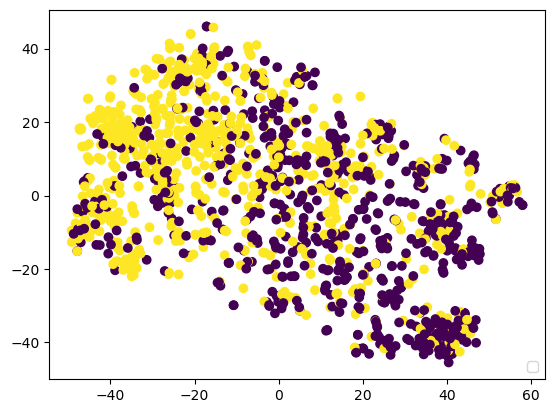

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9978118161925602
Training MCC Score: 0.9956282770414164
Training F1 Score: 0.9978093500752321
Training AUC VALUE: 0.9999786983861897
Training kappa Score: 0.99561872115232
Training Precision: 0.995774647887324
Training Recall: 1.0
Training Sensitivity: 1.0
Training Specificity: 0.9954819277108434
Training CCR: 0.9978118161925602
Training PPV: 0.995774647887324


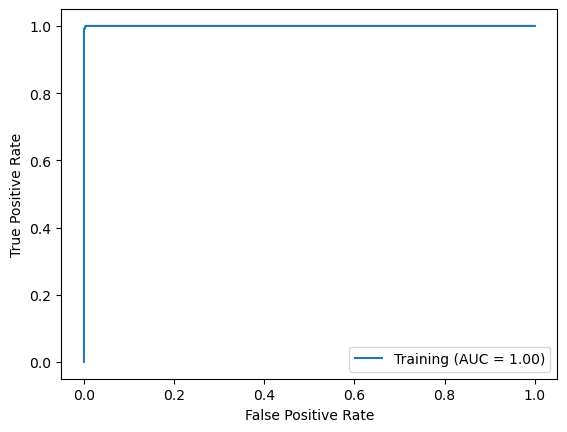

Testing Accuracy: 0.7364864864864865
Testing MCC Score: 0.47108438718679135
Testing F1 Score: 0.7355084085597763
Testing AUC VALUE: 0.7888460832874701
Testing kappa Score: 0.4710410557184751
Testing Precision: 0.7564102564102564
Testing Recall: 0.7468354430379747
Testing Sensitivity: 0.7468354430379747
Testing Specificity: 0.7246376811594203
Testing CCR: 0.7364864864864865
Testing PPV: 0.7564102564102564


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


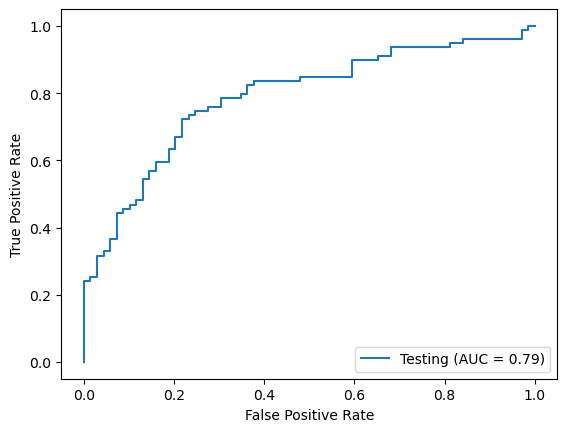

2024-11-04 19:54:16,809:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:54:16,810:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:54:16,811:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #2


C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


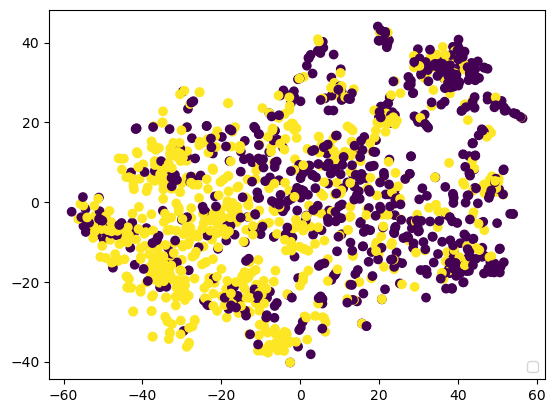

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9970824215900802
Training MCC Score: 0.9941638713149749
Training F1 Score: 0.997079810006603
Training AUC VALUE: 0.9999137284640685
Training kappa Score: 0.9941596324530183
Training Precision: 0.9985815602836879
Training Recall: 0.9957567185289957
Training Sensitivity: 0.9957567185289957
Training Specificity: 0.9984939759036144
Training CCR: 0.9970824215900802
Training PPV: 0.9985815602836879


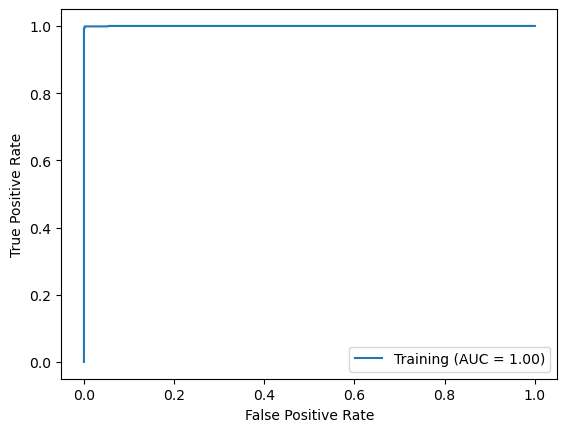

Testing Accuracy: 0.7297297297297297
Testing MCC Score: 0.4557017290632041
Testing F1 Score: 0.7256719184430028
Testing AUC VALUE: 0.7712346358466337
Testing kappa Score: 0.45296618000369626
Testing Precision: 0.7241379310344828
Testing Recall: 0.7974683544303798
Testing Sensitivity: 0.7974683544303798
Testing Specificity: 0.6521739130434783
Testing CCR: 0.7297297297297297
Testing PPV: 0.7241379310344828


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


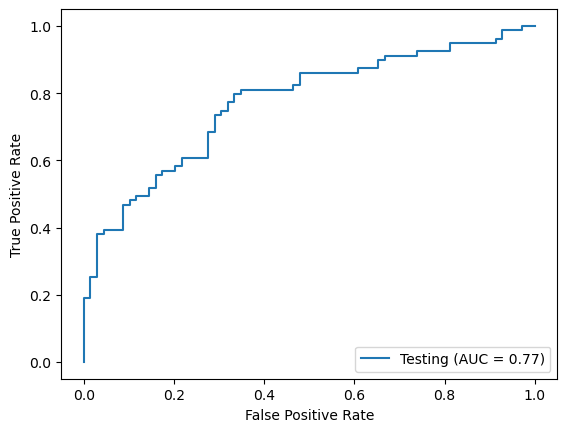

2024-11-04 19:54:20,624:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:54:20,625:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:54:20,625:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #3


C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


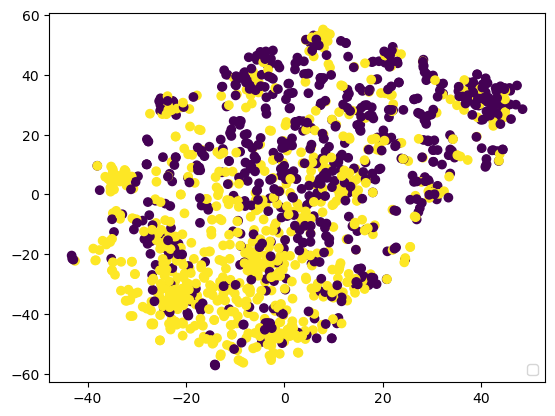

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9992706053975201
Training MCC Score: 0.9985409057232624
Training F1 Score: 0.9992699202343922
Training AUC VALUE: 0.9999978698386189
Training kappa Score: 0.998539841246343
Training Precision: 1.0
Training Recall: 0.9985855728429985
Training Sensitivity: 0.9985855728429985
Training Specificity: 1.0
Training CCR: 0.9992706053975201
Training PPV: 1.0


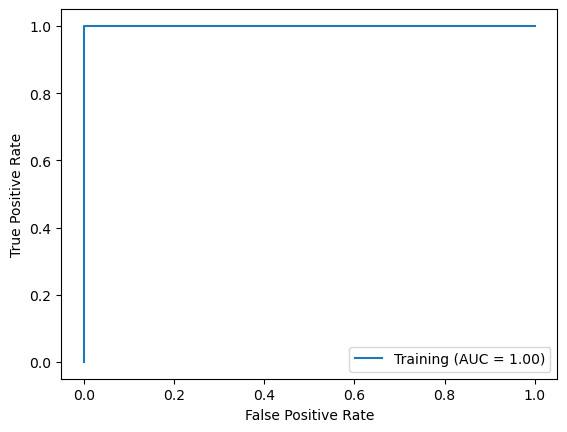

Testing Accuracy: 0.6081081081081081
Testing MCC Score: 0.2196375320552171
Testing F1 Score: 0.6080365296803653
Testing AUC VALUE: 0.6672170243991927
Testing kappa Score: 0.21835731196503372
Testing Precision: 0.647887323943662
Testing Recall: 0.5822784810126582
Testing Sensitivity: 0.5822784810126582
Testing Specificity: 0.6376811594202898
Testing CCR: 0.6081081081081081
Testing PPV: 0.647887323943662


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


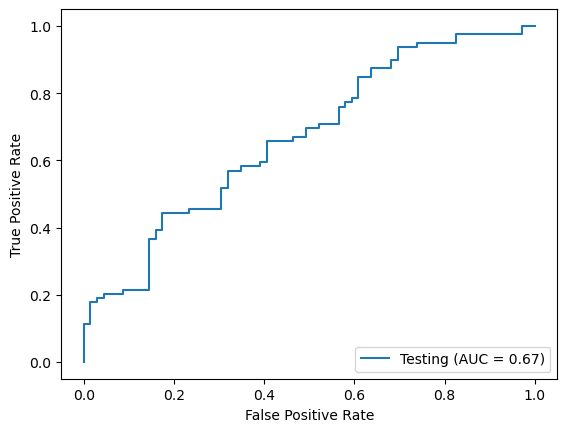

2024-11-04 19:54:24,453:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:54:24,454:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:54:24,455:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #4


C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


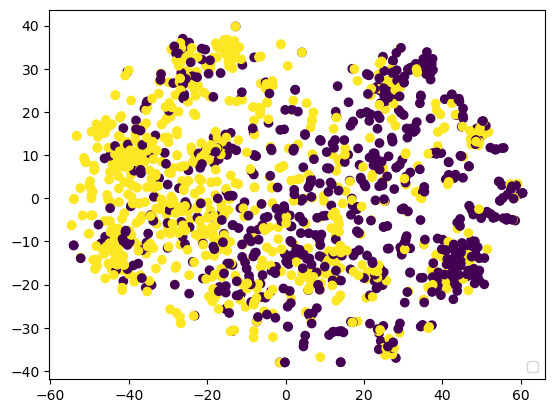

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9948942377826404
Training MCC Score: 0.9897893194464307
Training F1 Score: 0.9948898879204449
Training AUC VALUE: 0.9999360951585693
Training kappa Score: 0.9897798248182956
Training Precision: 0.9971590909090909
Training Recall: 0.9929278642149929
Training Sensitivity: 0.9929278642149929
Training Specificity: 0.9969879518072289
Training CCR: 0.9948942377826404
Training PPV: 0.9971590909090909


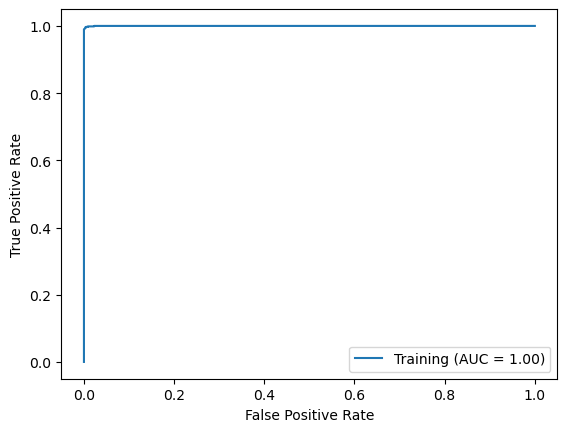

Testing Accuracy: 0.6891891891891891
Testing MCC Score: 0.37451828604101056
Testing F1 Score: 0.6871323529411765
Testing AUC VALUE: 0.7451843698403963
Testing kappa Score: 0.3743797096122037
Testing Precision: 0.7037037037037037
Testing Recall: 0.7215189873417721
Testing Sensitivity: 0.7215189873417721
Testing Specificity: 0.6521739130434783
Testing CCR: 0.6891891891891891
Testing PPV: 0.7037037037037037


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


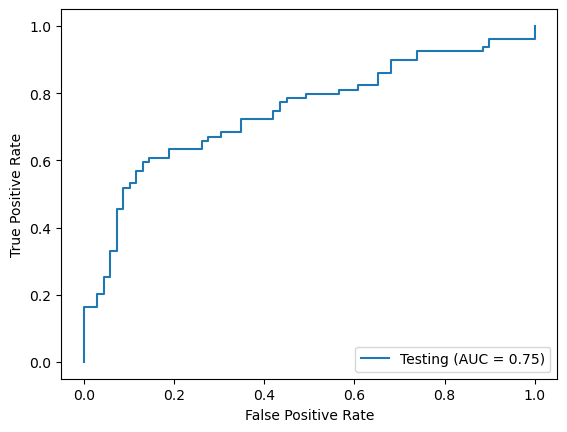

2024-11-04 19:54:28,365:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:54:28,366:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:54:28,367:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #5


C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


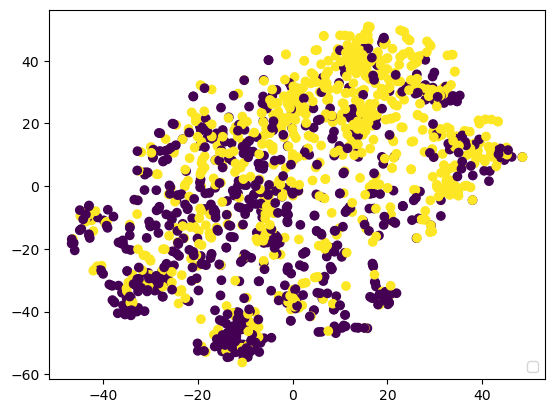

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9985412107950401
Training MCC Score: 0.9970835340862849
Training F1 Score: 0.9985396374977631
Training AUC VALUE: 0.999993609515857
Training kappa Score: 0.9970792812177118
Training Precision: 0.997179125528914
Training Recall: 1.0
Training Sensitivity: 1.0
Training Specificity: 0.9969879518072289
Training CCR: 0.9985412107950401
Training PPV: 0.997179125528914


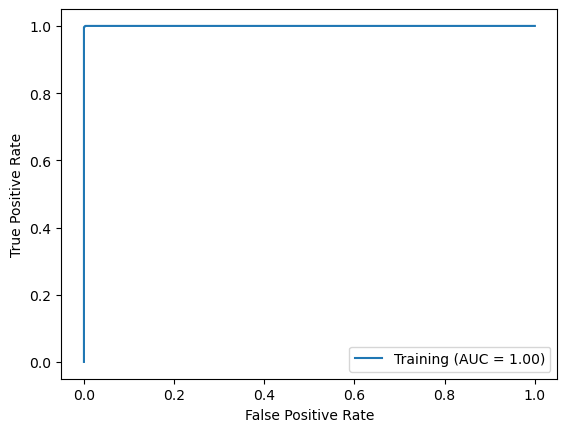

Testing Accuracy: 0.7702702702702703
Testing MCC Score: 0.5449721917133202
Testing F1 Score: 0.7702283105022831
Testing AUC VALUE: 0.8279214822968263
Testing kappa Score: 0.541795665634675
Testing Precision: 0.8169014084507042
Testing Recall: 0.7341772151898734
Testing Sensitivity: 0.7341772151898734
Testing Specificity: 0.8115942028985508
Testing CCR: 0.7702702702702703
Testing PPV: 0.8169014084507042


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


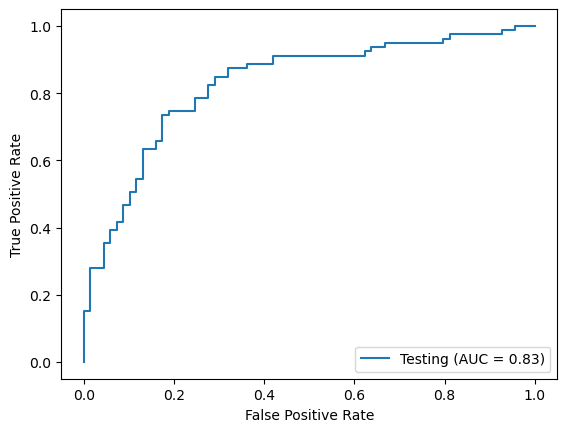

2024-11-04 19:54:32,531:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:54:32,531:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:54:32,532:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #6


C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


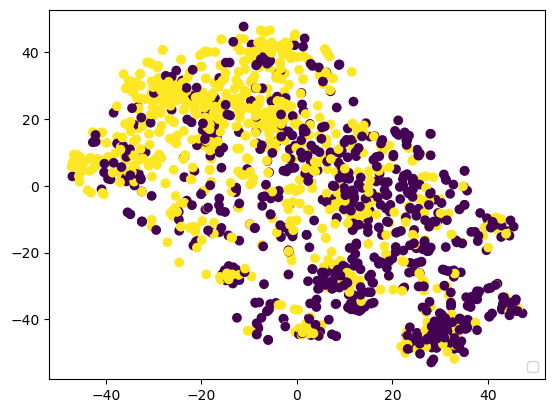

0  
1.0    707
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9985412107950401
Training MCC Score: 0.9970795487466131
Training F1 Score: 0.9985397743733064
Training AUC VALUE: 0.999991479354476
Training kappa Score: 0.9970795487466131
Training Precision: 0.9985855728429985
Training Recall: 0.9985855728429985
Training Sensitivity: 0.9985855728429985
Training Specificity: 0.9984939759036144
Training CCR: 0.9985412107950401
Training PPV: 0.9985855728429985


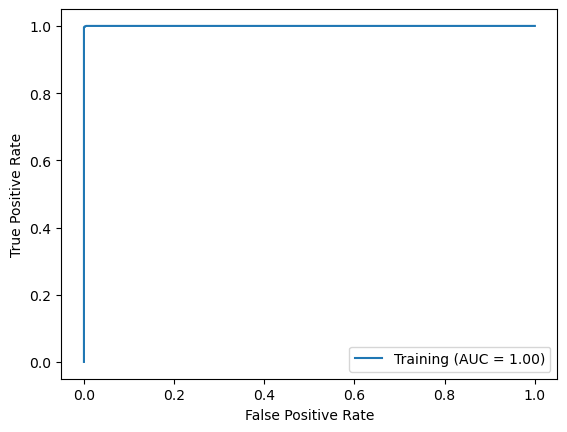

Testing Accuracy: 0.6824324324324325
Testing MCC Score: 0.3613995048747762
Testing F1 Score: 0.6806684111463067
Testing AUC VALUE: 0.7596771234635846
Testing kappa Score: 0.36136614028644876
Testing Precision: 0.7
Testing Recall: 0.7088607594936709
Testing Sensitivity: 0.7088607594936709
Testing Specificity: 0.6521739130434783
Testing CCR: 0.6824324324324325
Testing PPV: 0.7


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


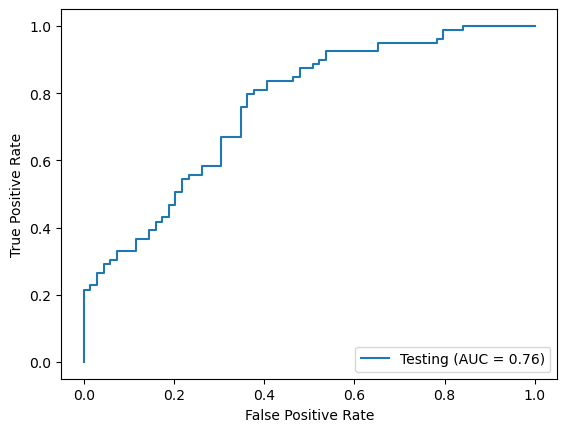

2024-11-04 19:54:36,371:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:54:36,372:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:54:36,372:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #7


C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


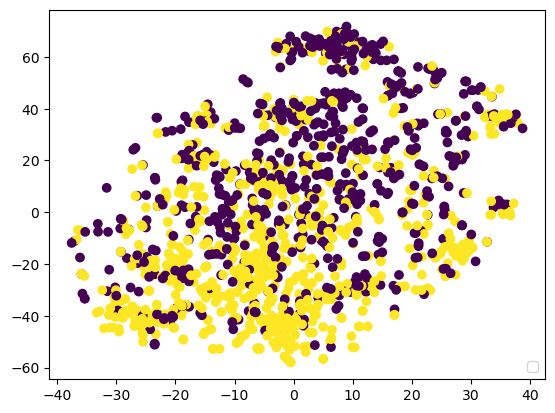

0  
1.0    708
0.0    664
Name: count, dtype: int64
Training Accuracy: 0.9978134110787172
Training MCC Score: 0.9956235845551618
Training F1 Score: 0.9978112611570642
Training AUC VALUE: 0.9999861735075898
Training kappa Score: 0.9956225246419106
Training Precision: 0.9985855728429985
Training Recall: 0.9971751412429378
Training Sensitivity: 0.9971751412429378
Training Specificity: 0.9984939759036144
Training CCR: 0.9978134110787172
Training PPV: 0.9985855728429985


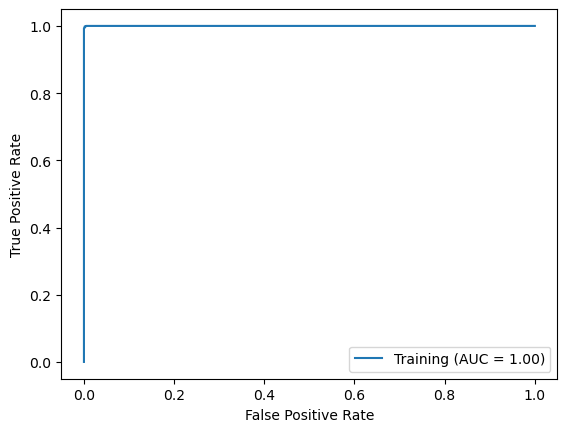

Testing Accuracy: 0.6756756756756757
Testing MCC Score: 0.3486244400719358
Testing F1 Score: 0.6741882223445239
Testing AUC VALUE: 0.7287545787545788
Testing kappa Score: 0.3484959647835657
Testing Precision: 0.6875
Testing Recall: 0.7051282051282052
Testing Sensitivity: 0.7051282051282052
Testing Specificity: 0.6428571428571429
Testing CCR: 0.6756756756756757
Testing PPV: 0.6875


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


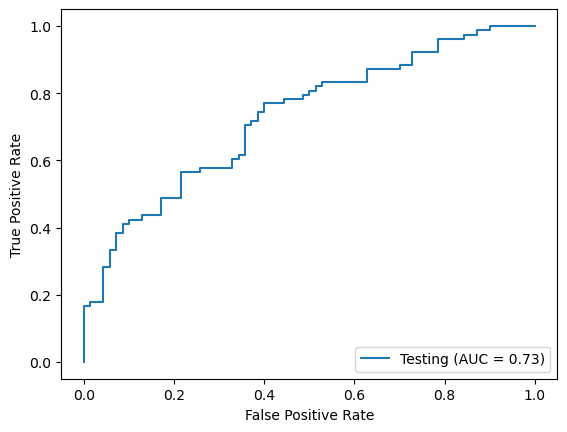

2024-11-04 19:54:40,220:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:54:40,220:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:54:40,221:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #8


C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


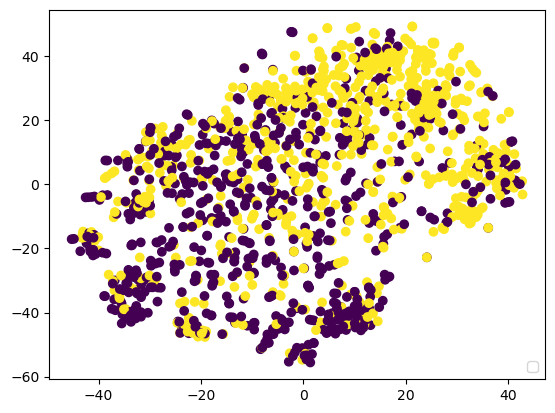

0  
1.0    708
0.0    665
Name: count, dtype: int64
Training Accuracy: 0.9978150036416606
Training MCC Score: 0.9956358388675404
Training F1 Score: 0.9978131475544045
Training AUC VALUE: 0.9999192897497983
Training kappa Score: 0.9956263160074286
Training Precision: 1.0
Training Recall: 0.9957627118644068
Training Sensitivity: 0.9957627118644068
Training Specificity: 1.0
Training CCR: 0.9978150036416606
Training PPV: 1.0


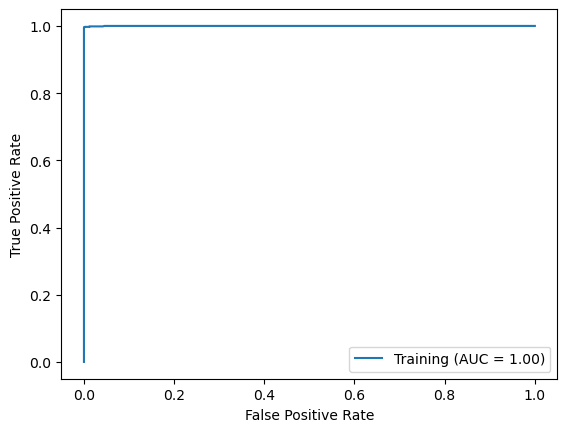

Testing Accuracy: 0.6666666666666666
Testing MCC Score: 0.3433572943066506
Testing F1 Score: 0.6664196730421896
Testing AUC VALUE: 0.7441471571906354
Testing kappa Score: 0.33802040253653154
Testing Precision: 0.7230769230769231
Testing Recall: 0.6025641025641025
Testing Sensitivity: 0.6025641025641025
Testing Specificity: 0.7391304347826086
Testing CCR: 0.6666666666666666
Testing PPV: 0.7230769230769231


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


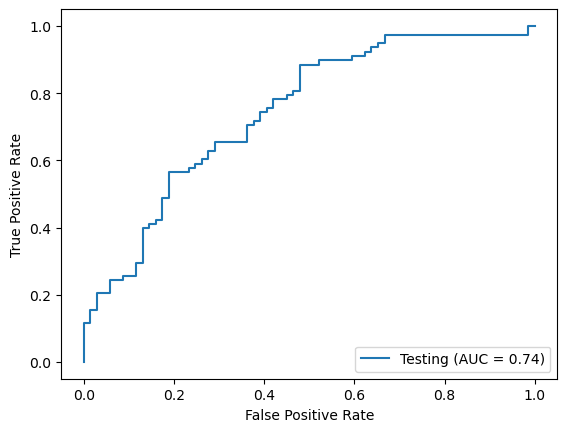

2024-11-04 19:54:44,083:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:54:44,084:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:54:44,085:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #9


C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


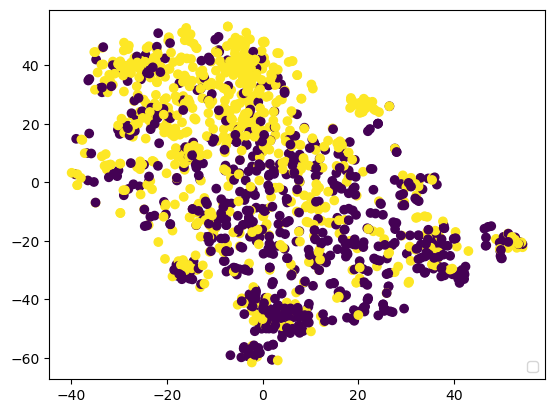

0  
1.0    708
0.0    665
Name: count, dtype: int64
Training Accuracy: 0.9949016751638747
Training MCC Score: 0.9897948574222121
Training F1 Score: 0.994896899963629
Training AUC VALUE: 0.9999033600951532
Training kappa Score: 0.9897938053463852
Training Precision: 0.9957567185289957
Training Recall: 0.9943502824858758
Training Sensitivity: 0.9943502824858758
Training Specificity: 0.9954887218045113
Training CCR: 0.9949016751638747
Training PPV: 0.9957567185289957


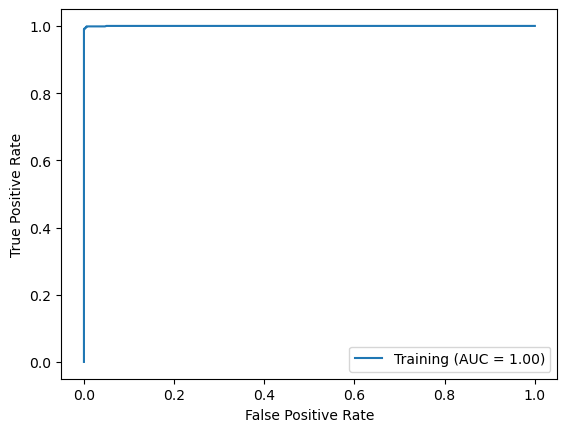

Testing Accuracy: 0.6938775510204082
Testing MCC Score: 0.3860008491161576
Testing F1 Score: 0.6929682060802971
Testing AUC VALUE: 0.7300260126347083
Testing kappa Score: 0.38596491228070184
Testing Precision: 0.7142857142857143
Testing Recall: 0.7051282051282052
Testing Sensitivity: 0.7051282051282052
Testing Specificity: 0.6811594202898551
Testing CCR: 0.6938775510204082
Testing PPV: 0.7142857142857143


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


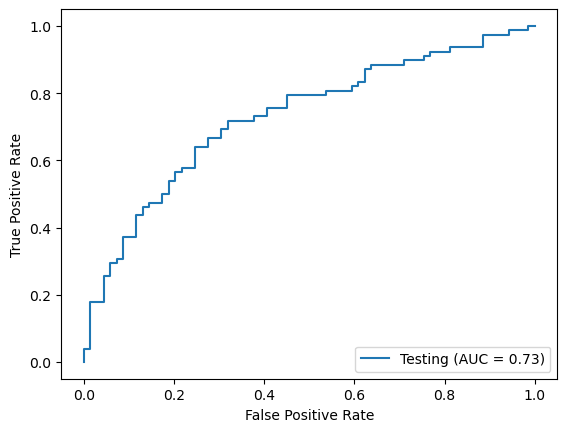

2024-11-04 19:54:47,922:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2024-11-04 19:54:47,923:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2024-11-04 19:54:47,924:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\manifold\_t_sne.p

Fold #10


C:\Users\DELL\AppData\Local\Temp\ipykernel_36440\3354205775.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


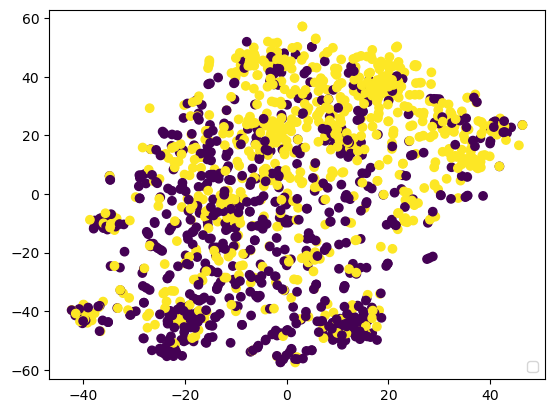

0  
1.0    708
0.0    665
Name: count, dtype: int64
Training Accuracy: 0.9970866715222141
Training MCC Score: 0.9941723816043915
Training F1 Score: 0.9970840713414971
Training AUC VALUE: 0.9999872562762839
Training kappa Score: 0.9941681550684595
Training Precision: 0.9985835694050992
Training Recall: 0.9957627118644068
Training Sensitivity: 0.9957627118644068
Training Specificity: 0.9984962406015038
Training CCR: 0.9970866715222141
Training PPV: 0.9985835694050992


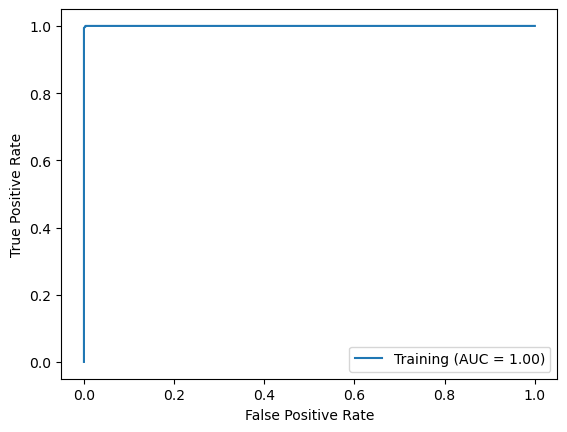

Testing Accuracy: 0.7551020408163265
Testing MCC Score: 0.5083612040133779
Testing F1 Score: 0.7541806020066889
Testing AUC VALUE: 0.8221850613154962
Testing kappa Score: 0.508361204013378
Testing Precision: 0.7692307692307693
Testing Recall: 0.7692307692307693
Testing Sensitivity: 0.7692307692307693
Testing Specificity: 0.7391304347826086
Testing CCR: 0.7551020408163265
Testing PPV: 0.7692307692307693


C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python39\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


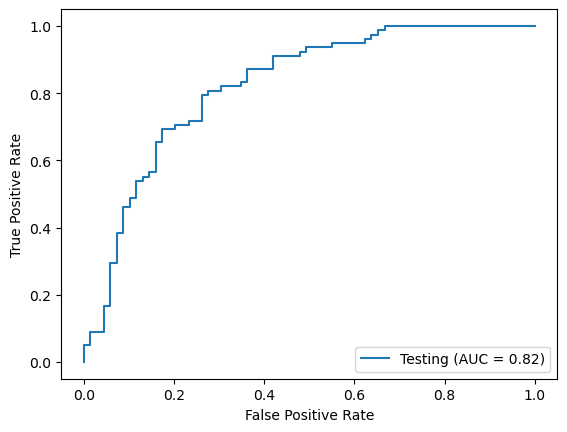

"\n    all_predictions = []\n    all_probabilities = []\n    all_labels = []\n    # 拼接训练集和测试集的预测结果和真实标签\n    all_predictions.extend(y_train_pred)\n    all_probabilities.extend(y_train_prob)\n    all_labels.extend(Final_Ytrain)\n    \n    all_predictions.extend(y_test_pred)\n    all_probabilities.extend(y_test_prob)\n    all_labels.extend(Test_y)\n\n    # 计算总的评价指标\n    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))\n"

In [99]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

Train_Fold_outs_1 = []
Test_Fold_outs_1 = []
models_1 = []

# 用于存储训练和测试集的预测结果和标签

total_metrics = []

# 定义 10 折交叉验证
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 获取特征和标签
X = Data[f_list].values  # 替换 Data 为你的数据集，f_list 为你的特征列表
y = Data['status'].values

# 10 折交叉验证
for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f'Fold #{fold+1}')
    
    # 获取训练集和测试集
    Train_x, Test_x = X[train_index], X[test_index]
    Train_y, Test_y = y[train_index], y[test_index]
    
    # Upsampling
    Final_Xtrain, Final_Ytrain = Smote(pd.DataFrame(Train_x, columns=f_list), pd.Series(Train_y), 0.5)
    print(Final_Ytrain.value_counts())
    Final_Ytrain = Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype=np.float64)
    Test_x_filtered = pd.DataFrame(Test_x, dtype=np.float64)

    # 使用 KNeighborsClassifier
    rf = RandomForestClassifier(max_features=Parameters['max_features'],
                        max_depth=Parameters['max_depth'],
                        min_samples_split=Parameters['min_samples_split'],
                        min_samples_leaf=Parameters['min_samples_leaf'],
                        bootstrap=Parameters['bootstrap'],
                        n_estimators=Parameters['n_estimators'])

    
    # 拟合模型
    rf.fit(Final_Xtrain, Final_Ytrain)
    models_1.append(rf)
    
    # 训练集预测
    y_train_pred = rf.predict(Final_Xtrain)
    y_train_prob = rf.predict_proba(Final_Xtrain)[:, 1]
    Train_Fold_outs_1.append(Scoring_metrices(y_train_pred, y_train_prob, Final_Ytrain, 'Training'))

    # 测试集预测
    y_test_pred = rf.predict(Test_x_filtered)
    y_test_prob = rf.predict_proba(Test_x_filtered)[:, 1]
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred, y_test_prob, Test_y, 'Testing'))
'''
    all_predictions = []
    all_probabilities = []
    all_labels = []
    # 拼接训练集和测试集的预测结果和真实标签
    all_predictions.extend(y_train_pred)
    all_probabilities.extend(y_train_prob)
    all_labels.extend(Final_Ytrain)
    
    all_predictions.extend(y_test_pred)
    all_probabilities.extend(y_test_prob)
    all_labels.extend(Test_y)

    # 计算总的评价指标
    total_metrics.append(Scoring_metrices(all_predictions, all_probabilities, all_labels, 'Overall'))
'''

2026-04-01 09:03:43,640:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 09:03:43,641:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 09:03:43,642:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #1


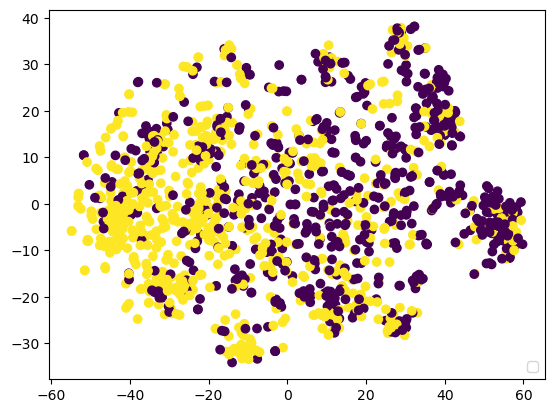

Testing Accuracy: 0.7297297297297297
Testing MCC Score: 0.45565792685268364
Testing F1 Score: 0.7272894785332596
Testing AUC VALUE: 0.7802238121445605
Testing kappa Score: 0.45498066654391456
Testing Precision: 0.7349397590361446
Testing Recall: 0.7721518987341772
Testing Sensitivity: 0.7721518987341772
Testing Specificity: 0.6811594202898551
Testing CCR: 0.7297297297297297
Testing PPV: 0.7349397590361446


D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


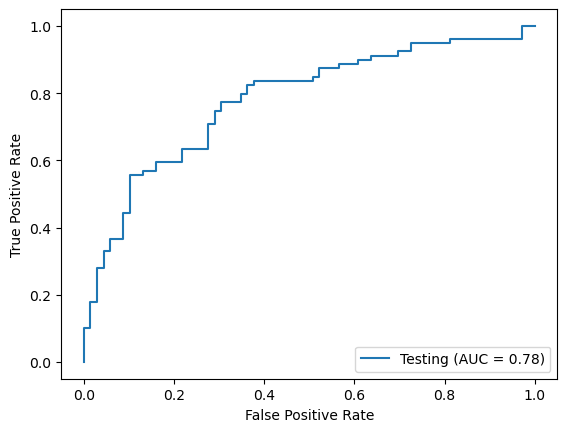

2026-04-01 09:03:51,056:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 09:03:51,058:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 09:03:51,059:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #2


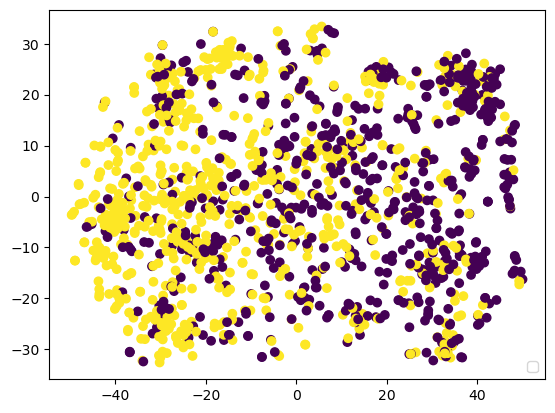

Testing Accuracy: 0.7094594594594594
Testing MCC Score: 0.41452920314051395
Testing F1 Score: 0.7064440241708567
Testing AUC VALUE: 0.7666483214089158
Testing kappa Score: 0.4135643199410247
Testing Precision: 0.7142857142857143
Testing Recall: 0.759493670886076
Testing Sensitivity: 0.759493670886076
Testing Specificity: 0.6521739130434783
Testing CCR: 0.7094594594594594
Testing PPV: 0.7142857142857143


D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


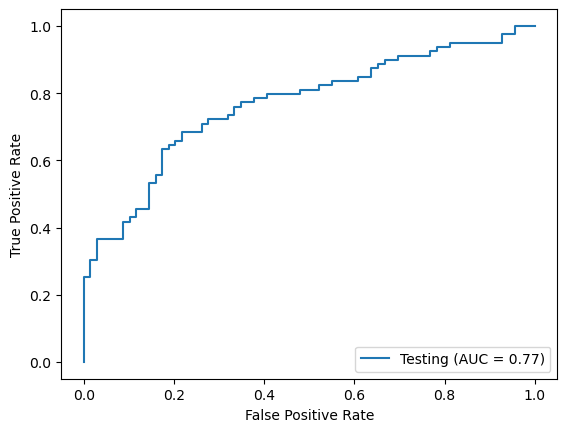

2026-04-01 09:03:58,396:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 09:03:58,398:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 09:03:58,399:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #3


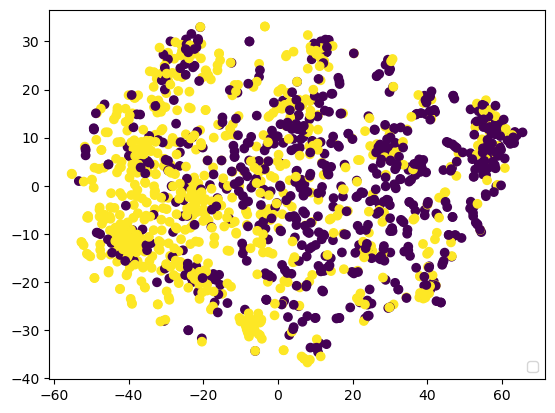

Testing Accuracy: 0.6351351351351351
Testing MCC Score: 0.27609612915061454
Testing F1 Score: 0.6351351351351351
Testing AUC VALUE: 0.6835443037974683
Testing kappa Score: 0.27358662061443373
Testing Precision: 0.6811594202898551
Testing Recall: 0.5949367088607594
Testing Sensitivity: 0.5949367088607594
Testing Specificity: 0.6811594202898551
Testing CCR: 0.6351351351351351
Testing PPV: 0.6811594202898551


D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


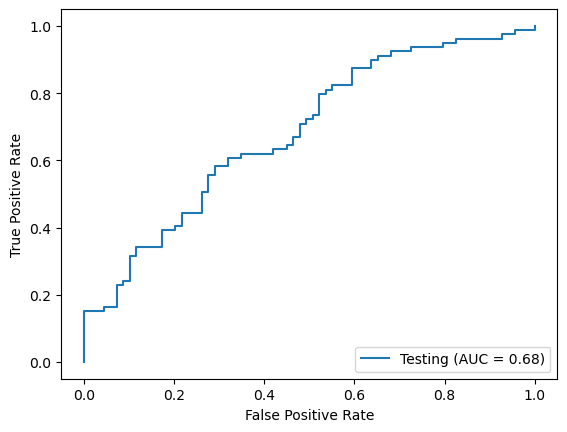

2026-04-01 09:04:05,850:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 09:04:05,851:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 09:04:05,853:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #4


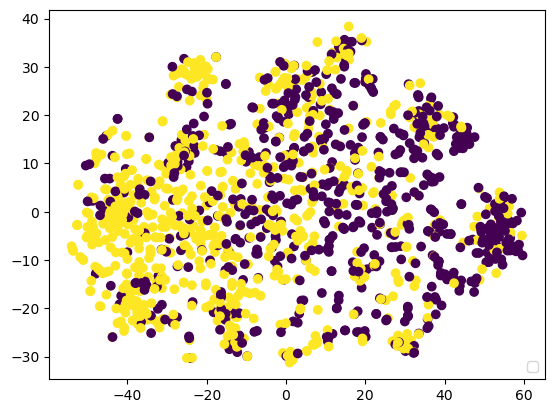

Testing Accuracy: 0.6418918918918919
Testing MCC Score: 0.2787461580229547
Testing F1 Score: 0.6391074304117783
Testing AUC VALUE: 0.7429829389102917
Testing kappa Score: 0.278513612950699
Testing Precision: 0.6585365853658537
Testing Recall: 0.6835443037974683
Testing Sensitivity: 0.6835443037974683
Testing Specificity: 0.5942028985507246
Testing CCR: 0.6418918918918919
Testing PPV: 0.6585365853658537


D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


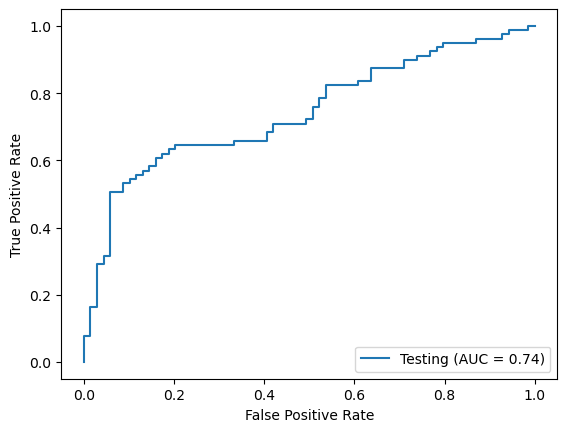

2026-04-01 09:04:13,221:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 09:04:13,223:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 09:04:13,224:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #5


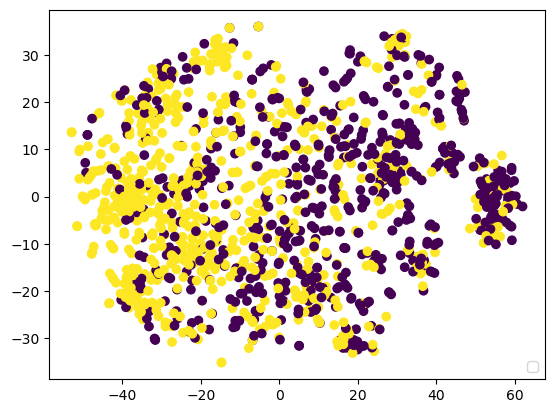

Testing Accuracy: 0.7297297297297297
Testing MCC Score: 0.45963867066595404
Testing F1 Score: 0.7292847997073351
Testing AUC VALUE: 0.8073747936158504
Testing kappa Score: 0.45896545421312374
Testing Precision: 0.76
Testing Recall: 0.7215189873417721
Testing Sensitivity: 0.7215189873417721
Testing Specificity: 0.7391304347826086
Testing CCR: 0.7297297297297297
Testing PPV: 0.76


D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


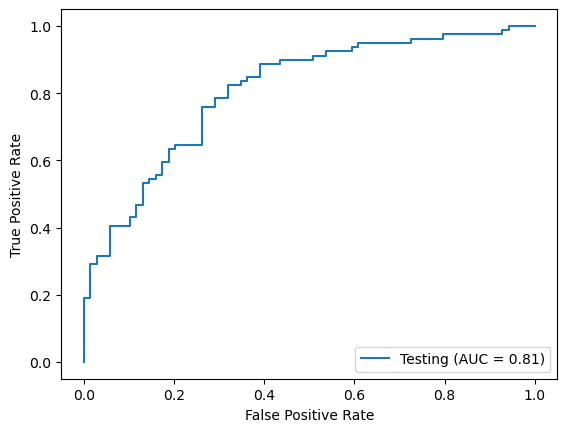

2026-04-01 09:04:20,486:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 09:04:20,487:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 09:04:20,489:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #6


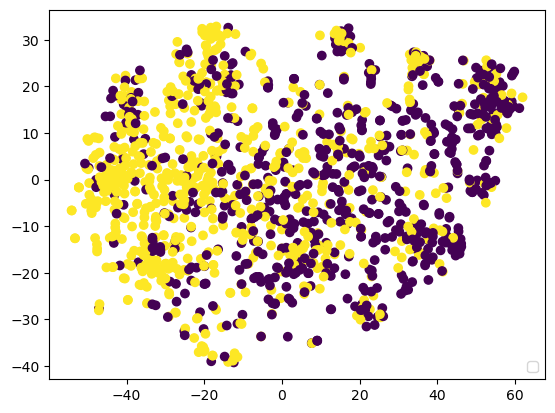

Testing Accuracy: 0.7094594594594594
Testing MCC Score: 0.4157563409738279
Testing F1 Score: 0.7078455676444934
Testing AUC VALUE: 0.7488534213905705
Testing kappa Score: 0.4157179581344106
Testing Precision: 0.725
Testing Recall: 0.7341772151898734
Testing Sensitivity: 0.7341772151898734
Testing Specificity: 0.6811594202898551
Testing CCR: 0.7094594594594594
Testing PPV: 0.725


D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


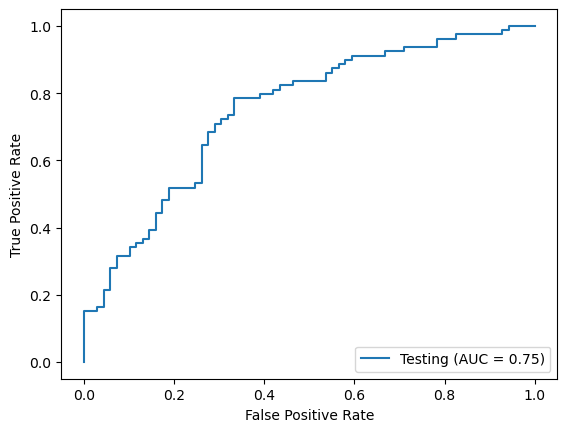

2026-04-01 09:04:27,797:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 09:04:27,799:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 09:04:27,800:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #7


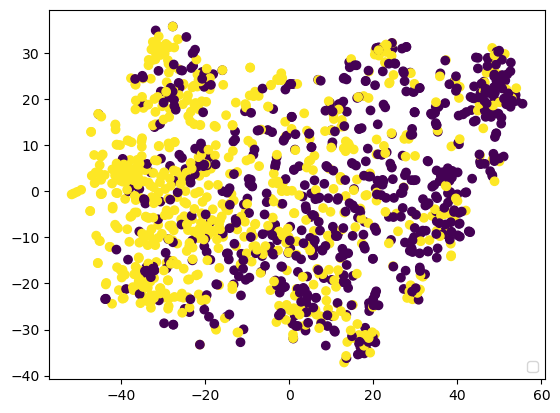

Testing Accuracy: 0.668918918918919
Testing MCC Score: 0.3354414118878709
Testing F1 Score: 0.6676900517802319
Testing AUC VALUE: 0.7282051282051283
Testing kappa Score: 0.33541055718475066
Testing Precision: 0.6835443037974683
Testing Recall: 0.6923076923076923
Testing Sensitivity: 0.6923076923076923
Testing Specificity: 0.6428571428571429
Testing CCR: 0.668918918918919
Testing PPV: 0.6835443037974683


D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


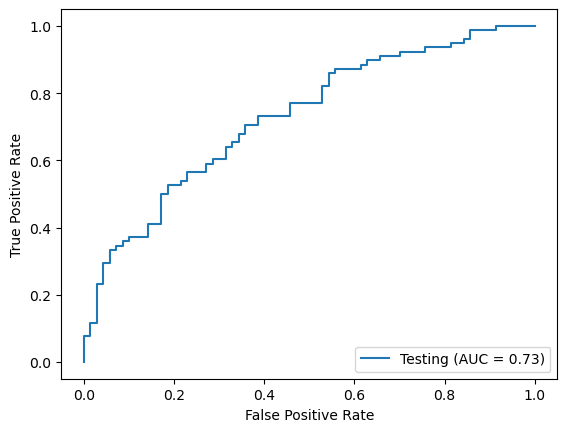

2026-04-01 09:04:35,107:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 09:04:35,109:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 09:04:35,110:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #8


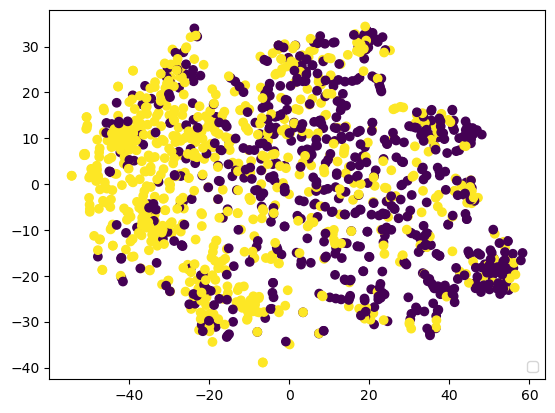

Testing Accuracy: 0.6870748299319728
Testing MCC Score: 0.380509742342835
Testing F1 Score: 0.6870603480192521
Testing AUC VALUE: 0.7545522110739503
Testing kappa Score: 0.3770038695411829
Testing Precision: 0.7352941176470589
Testing Recall: 0.6410256410256411
Testing Sensitivity: 0.6410256410256411
Testing Specificity: 0.7391304347826086
Testing CCR: 0.6870748299319728
Testing PPV: 0.7352941176470589


D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


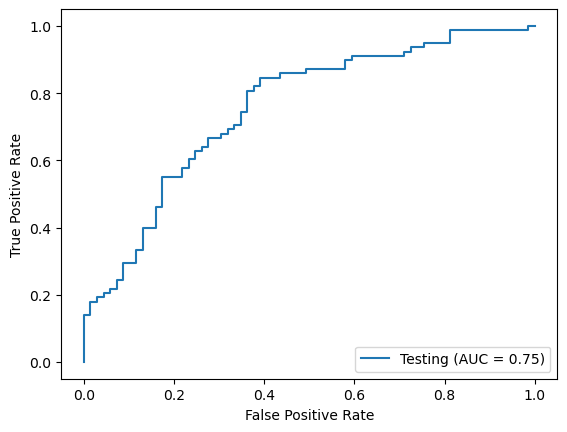

2026-04-01 09:04:42,429:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 09:04:42,431:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 09:04:42,432:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #9


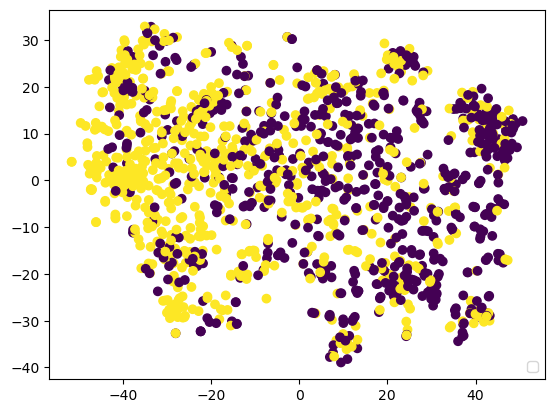

Testing Accuracy: 0.6870748299319728
Testing MCC Score: 0.3717948717948718
Testing F1 Score: 0.6858974358974359
Testing AUC VALUE: 0.7238944630248978
Testing kappa Score: 0.3717948717948718
Testing Precision: 0.7051282051282052
Testing Recall: 0.7051282051282052
Testing Sensitivity: 0.7051282051282052
Testing Specificity: 0.6666666666666666
Testing CCR: 0.6870748299319728
Testing PPV: 0.7051282051282052


D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


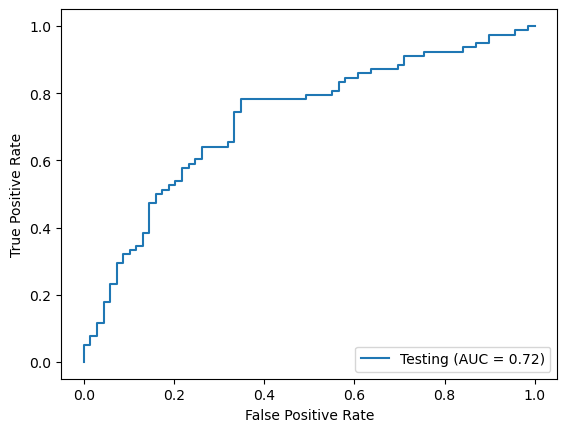

2026-04-01 09:04:49,733:INFO:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
INFO:smote_variants:MSMOTE: Running sampling via ('MSMOTE', "{'proportion': 0.5, 'n_neighbors': 5, 'nn_params': {}, 'n_jobs': 1, 'random_state': 50, 'class_name': 'MSMOTE'}")
2026-04-01 09:04:49,735:INFO:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: NN fitting with metric minkowski
2026-04-01 09:04:49,736:INFO:NearestNeighborsWithMetricTensor: kneighbors query minkowski
INFO:smote_variants:NearestNeighborsWithMetricTensor: kneighbors query minkowski


Fold #10


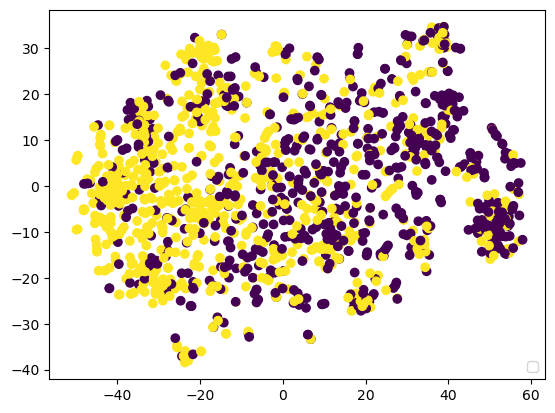

Testing Accuracy: 0.7414965986394558
Testing MCC Score: 0.4820935594251098
Testing F1 Score: 0.740909090909091
Testing AUC VALUE: 0.8099219620958752
Testing kappa Score: 0.4819143016138008
Testing Precision: 0.7631578947368421
Testing Recall: 0.7435897435897436
Testing Sensitivity: 0.7435897435897436
Testing Specificity: 0.7391304347826086
Testing CCR: 0.7414965986394558
Testing PPV: 0.7631578947368421


D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\ProgramData\miniforge3\envs\tensorflow\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


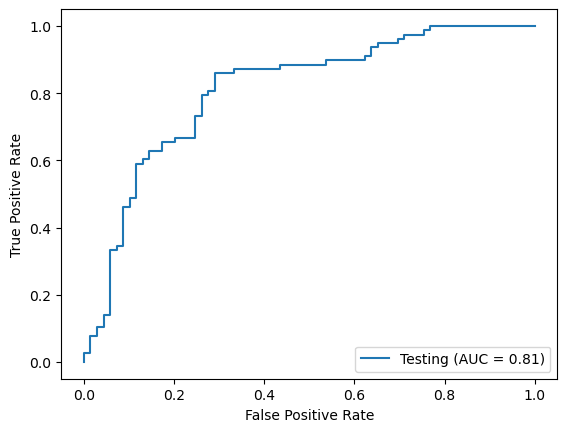


✅ 10折交叉验证执行完毕！
🌟 科学的全局 10-Fold CV AUC: 0.7513
📁 完整预测数据已保存至: 10fold_CV_OOF_predictions.csv


In [50]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import numpy as np

Train_Fold_outs_1 = []
Test_Fold_outs_1 = []
models_1 = []

# >>> 核心修改：用于收集全部 10 折的“袋外”(Out-Of-Fold) 预测结果 <<<
oof_predictions = []

# 定义 10 折交叉验证
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 获取特征和标签
X = Data[f_list].values  # 替换 Data 为你的数据集，f_list 为你的特征列表
y = Data['status'].values

for fold, (train_index, test_index) in enumerate(kf.split(X, y)):
    print(f'Fold #{fold+1}')
    
    Train_x, Test_x = X[train_index], X[test_index]
    Train_y, Test_y = y[train_index], y[test_index]
    
    # Upsampling
    Final_Xtrain, Final_Ytrain = Smote(pd.DataFrame(Train_x, columns=f_list), pd.Series(Train_y), 0.5)
    Final_Ytrain = Final_Ytrain.values.ravel()
    Final_Xtrain = pd.DataFrame(Final_Xtrain, dtype=np.float64)
    Test_x_filtered = pd.DataFrame(Test_x, dtype=np.float64)

    # >>> 关键修复：直接解包最佳参数，解决 RandomizedSearchCV 报错 <<<
    rf = RandomForestClassifier(**Parameters.best_params_)

    # 训练模型
    rf.fit(Final_Xtrain, Final_Ytrain)
    models_1.append(rf)
    
    # 预测这一折的验证集
    y_test_pred = rf.predict(Test_x_filtered)
    y_test_prob = rf.predict_proba(Test_x_filtered)[:, 1]
    Test_Fold_outs_1.append(Scoring_metrices(y_test_pred, y_test_prob, Test_y, 'Testing'))
    
    # >>> 将当前折的预测结果和真实标签打包，存入列表 <<<
    fold_df = pd.DataFrame({
        'Fold': fold + 1,
        'Original_Index': test_index,  # 记录原始索引，方便以后追溯
        'True_Label': Test_y,
        'Pred_Prob': y_test_prob
    })
    oof_predictions.append(fold_df)


# ==========================================================
# 交叉验证结束后：合并数据，计算科学的全局 OOF AUC 并导出
# ==========================================================
# 将 10 折的结果垂直拼接起来
final_oof_df = pd.concat(oof_predictions, ignore_index=True)

# 按照原始索引排序，恢复成和输入数据集一样的顺序
final_oof_df = final_oof_df.sort_values('Original_Index').reset_index(drop=True)

# 计算全局的 10-fold CV AUC
global_cv_auc = roc_auc_score(final_oof_df['True_Label'], final_oof_df['Pred_Prob'])

# 导出这个完整的 CSV 供你后续自己画图
csv_name = "10fold_CV_OOF_predictions.csv"
final_oof_df.to_csv(csv_name, index=False)

print("\n" + "="*50)
print(f"✅ 10折交叉验证执行完毕！")
print(f"🌟 科学的全局 10-Fold CV AUC: {global_cv_auc:.4f}")
print(f"📁 完整预测数据已保存至: {csv_name}")
print("="*50)


✅ 10折交叉验证执行完毕！
🌟 科学的全局 10-Fold CV AUC: 0.7481
📁 完整预测数据已保存至: 10fold_CV_OOF_predictions.csv

>>> 正在绘制并导出 ROC 曲线...


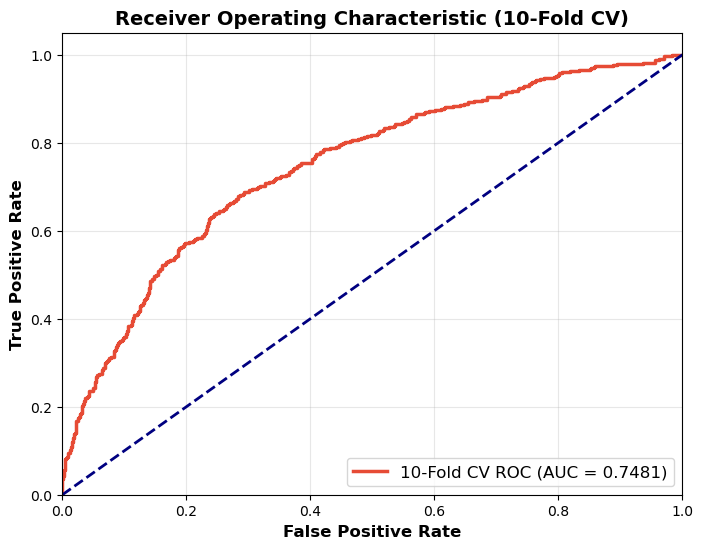

✅ ROC 曲线已成功导出为矢量图: 10fold_CV_ROC_curve.svg


In [48]:
# ==========================================================
# 交叉验证结束后：计算科学的全局 OOF AUC 并导出
# ==========================================================
# 将 10 折的结果垂直拼接起来
final_oof_df = pd.concat(oof_predictions, ignore_index=True)

# 按照原始索引排序，恢复成和输入数据集一样的顺序（可选，为了强迫症）
final_oof_df = final_oof_df.sort_values('Original_Index').reset_index(drop=True)

# 计算全局的 10-fold CV AUC
global_cv_auc = roc_auc_score(final_oof_df['True_Label'], final_oof_df['Pred_Prob'])

# 导出这个完整的 CSV
csv_name = "10fold_CV_OOF_predictions.csv"
final_oof_df.to_csv(csv_name, index=False)

print("\n" + "="*50)
print(f"✅ 10折交叉验证执行完毕！")
print(f"🌟 科学的全局 10-Fold CV AUC: {global_cv_auc:.4f}")
print(f"📁 完整预测数据已保存至: {csv_name}")
print("="*50)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ==========================================================
# 绘制 ROC 曲线并导出为 SVG
# ==========================================================
print("\n>>> 正在绘制并导出 ROC 曲线...")

# 计算 FPR (假阳性率) 和 TPR (真阳性率)
fpr, tpr, thresholds = roc_curve(final_oof_df['True_Label'], final_oof_df['Pred_Prob'])

# 设置画布大小
plt.figure(figsize=(8, 6))

# 绘制 ROC 曲线
plt.plot(fpr, tpr, color='#E64B35', lw=2.5, 
         label=f'10-Fold CV ROC (AUC = {global_cv_auc:.4f})')

# 绘制对角线 (随机猜测线)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 调整图表细节
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (10-Fold CV)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)

# 导出为 SVG 格式 (bbox_inches='tight' 防止边缘标签被裁剪)
svg_filename = "10fold_CV_ROC_curve.svg"
plt.savefig(svg_filename, format='svg', bbox_inches='tight')

plt.show()
print(f"✅ ROC 曲线已成功导出为矢量图: {svg_filename}")

In [101]:
#Analyse the training metrics sorted by descending Training Accuracy
pd.DataFrame.from_dict(Test_Fold_outs_1).sort_values(by=['Testing kappa Score:'],ascending = False)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
4,0.770270,0.544972,0.770228,0.827921,0.541796,0.816901,0.734177,0.734177,0.811594,0.770270,0.816901
9,0.755102,0.508361,0.754181,0.822185,0.508361,0.769231,0.769231,0.769231,0.739130,0.755102,0.769231
0,0.736486,0.471084,0.735508,0.788846,0.471041,0.756410,0.746835,0.746835,0.724638,0.736486,0.756410
1,0.729730,0.455702,0.725672,0.771235,0.452966,0.724138,0.797468,0.797468,0.652174,0.729730,0.724138
8,0.693878,0.386001,0.692968,0.730026,0.385965,0.714286,0.705128,0.705128,0.681159,0.693878,0.714286
3,0.689189,0.374518,0.687132,0.745184,0.374380,0.703704,0.721519,0.721519,0.652174,0.689189,0.703704
5,0.682432,0.361400,0.680668,0.759677,0.361366,0.700000,0.708861,0.708861,0.652174,0.682432,0.700000
6,0.675676,0.348624,0.674188,0.728755,0.348496,0.687500,0.705128,0.705128,0.642857,0.675676,0.687500
7,0.666667,0.343357,0.666420,0.744147,0.338020,0.723077,0.602564,0.602564,0.739130,0.666667,0.723077
2,0.608108,0.219638,0.608037,0.667217,0.218357,0.647887,0.582278,0.582278,0.637681,0.608108,0.647887


<Axes: >

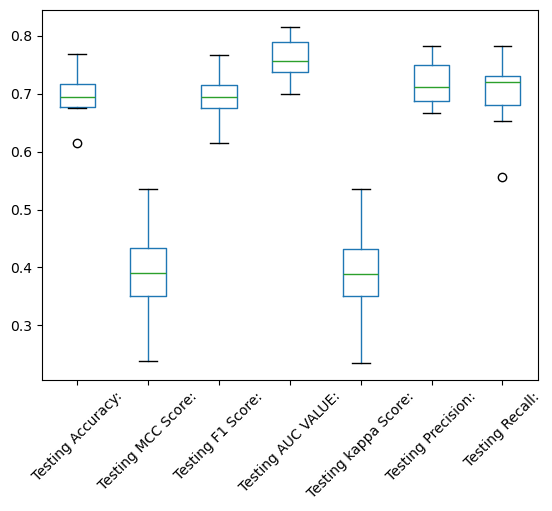

In [97]:
#To visualize the stability of the tuned model with each fold
(pd.DataFrame(Test_Fold_outs_1)).boxplot(grid=False,rot=45)

In [102]:
pd.DataFrame(Test_Fold_outs_1)

,Testing Accuracy:,Testing MCC Score:,Testing F1 Score:,Testing AUC VALUE:,Testing kappa Score:,Testing Precision:,Testing Recall:,Testing Sensitivity:,Testing Specificity:,Testing CCR:,Testing PPV:
0,0.736486,0.471084,0.735508,0.788846,0.471041,0.756410,0.746835,0.746835,0.724638,0.736486,0.756410
1,0.729730,0.455702,0.725672,0.771235,0.452966,0.724138,0.797468,0.797468,0.652174,0.729730,0.724138
2,0.608108,0.219638,0.608037,0.667217,0.218357,0.647887,0.582278,0.582278,0.637681,0.608108,0.647887
3,0.689189,0.374518,0.687132,0.745184,0.374380,0.703704,0.721519,0.721519,0.652174,0.689189,0.703704
4,0.770270,0.544972,0.770228,0.827921,0.541796,0.816901,0.734177,0.734177,0.811594,0.770270,0.816901
5,0.682432,0.361400,0.680668,0.759677,0.361366,0.700000,0.708861,0.708861,0.652174,0.682432,0.700000
6,0.675676,0.348624,0.674188,0.728755,0.348496,0.687500,0.705128,0.705128,0.642857,0.675676,0.687500
7,0.666667,0.343357,0.666420,0.744147,0.338020,0.723077,0.602564,0.602564,0.739130,0.666667,0.723077
8,0.693878,0.386001,0.692968,0.730026,0.385965,0.714286,0.705128,0.705128,0.681159,0.693878,0.714286
9,0.755102,0.508361,0.754181,0.822185,0.508361,0.769231,0.769231,0.769231,0.739130,0.755102,0.769231


In [103]:
TRAIN = Data.drop(['smiles','status'],axis=1)
TRAIN

,A1_0,A1_1,A1_2,A1_3,A1_4,A1_5,A1_6,A1_7,A1_8,A1_9,...,E5_118,E5_119,E5_120,E5_121,E5_122,E5_123,E5_124,E5_125,E5_126,E5_127
0,0.093736,0.085746,0.093669,-0.093733,-0.093736,-0.093322,0.093736,-0.093720,-0.093735,0.059581,...,-0.026415,0.119321,-0.005243,-0.015744,-0.010452,0.022232,0.016749,0.094246,-0.123218,-0.099457
1,-0.100092,-0.099088,-0.084504,-0.094028,0.085655,0.100332,0.010789,-0.028890,0.082395,-0.019364,...,0.014489,-0.014538,-0.108730,0.071725,0.064377,-0.096417,-0.119392,0.056950,0.105985,0.040311
2,-0.093479,-0.089258,0.069801,-0.090986,-0.082043,-0.043359,0.091742,-0.093448,0.089061,0.093108,...,-0.090673,-0.116404,0.065310,-0.059638,0.008421,-0.018185,-0.046916,-0.002449,0.137647,0.030377
3,-0.098335,-0.081193,0.049595,-0.061777,-0.066672,-0.022043,0.087456,-0.098040,0.047128,0.098288,...,-0.105842,-0.059380,-0.026610,0.045300,-0.068234,0.028847,-0.068210,0.011231,0.146784,-0.091332
4,-0.094336,-0.094267,-0.061746,-0.030467,-0.084787,-0.086779,0.066083,-0.093192,0.082983,0.091931,...,-0.096881,-0.104732,0.103063,0.032510,0.105347,-0.053153,0.019736,-0.092859,0.018258,0.047839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1472,-0.097989,-0.054378,-0.096215,0.073114,-0.087902,0.097986,0.097998,-0.097529,0.028526,-0.086145,...,-0.049566,0.039496,-0.066307,0.048998,-0.005742,-0.094280,-0.121242,0.153560,0.068190,0.045642
1473,-0.081419,0.101078,-0.099647,0.044550,-0.009900,0.103883,0.101900,-0.100953,-0.053084,-0.014191,...,-0.142667,0.068415,-0.097630,0.035883,0.006858,-0.021862,0.024690,0.098589,-0.101587,0.060199
1474,0.094904,0.095126,0.095131,-0.094880,0.095143,0.089252,0.094964,0.095148,0.062624,0.095051,...,-0.110147,-0.104988,0.055509,0.112147,0.034040,-0.109844,0.092205,-0.108522,-0.065427,0.010976
1475,0.054087,0.094914,0.095227,-0.094887,0.095227,-0.094630,0.066631,0.094708,0.069759,0.095189,...,-0.050667,-0.100252,0.050684,0.060956,-0.064519,-0.068106,0.005539,-0.104783,0.049453,-0.033316


In [104]:
TRAIN = TRAIN[f_list] #Use features of the selected (hyperparameter tuned) model here
TRAIN

,B1_27,B2_60,B2_123,B3_41,C1_0,C1_18,C1_41,C1_57,C1_95,C1_102,...,E4_106,E4_111,E4_112,E4_115,E4_117,E4_118,E4_120,E4_122,E5_37,E5_53
0,0.008161,-0.044923,-0.115314,0.110541,0.111802,0.079519,0.038651,0.090339,0.112063,-0.108310,...,-0.104486,0.036509,-0.103690,0.081017,0.104410,0.104427,-0.093174,0.104501,-0.078421,-0.037167
1,-0.134688,0.146781,-0.120272,0.102617,0.102073,0.074501,-0.022308,-0.106556,0.087306,-0.116226,...,0.101986,-0.094009,0.110870,-0.091607,-0.109663,0.015329,-0.100924,-0.067218,-0.002372,-0.047212
2,0.104418,-0.120238,-0.104308,-0.029646,0.107164,0.104460,-0.099634,-0.101821,0.102270,-0.080365,...,-0.110909,-0.021647,0.127086,-0.012874,0.073527,0.091587,-0.082653,0.115730,-0.064683,-0.031631
3,0.006089,-0.075256,0.004728,-0.142873,0.128630,0.114321,0.002644,-0.127032,0.123037,-0.117235,...,-0.157615,-0.021484,-0.109310,0.032714,0.062109,0.152177,0.073452,0.134571,-0.083946,-0.055002
4,0.076497,0.119623,-0.092002,-0.100371,0.127309,-0.076253,-0.105905,-0.091836,-0.056438,-0.126582,...,-0.106565,-0.006257,0.088841,0.103379,0.106258,0.106366,-0.013995,0.106495,-0.103301,-0.106638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1472,-0.094390,0.079961,-0.116200,0.086661,0.109037,-0.035442,-0.109343,-0.088878,0.111750,0.101252,...,0.052008,0.077878,0.021082,-0.003021,-0.131132,0.131182,0.094091,-0.042211,-0.087466,0.058811
1473,0.017661,-0.012102,0.156573,0.021632,0.124426,0.113679,-0.112086,-0.096931,0.133409,-0.116235,...,-0.032249,0.110956,0.113750,-0.020480,0.089054,0.111636,0.059335,0.065277,-0.061286,0.016523
1474,-0.064554,-0.125034,-0.036382,0.108596,-0.096365,-0.101802,-0.075226,-0.100907,0.101679,-0.093949,...,-0.091145,-0.095360,-0.094856,0.094533,0.094804,0.095276,-0.071868,0.093824,-0.120694,-0.113838
1475,-0.063731,0.040972,0.066624,0.109483,-0.071402,-0.110072,-0.118115,-0.111919,0.082837,0.115115,...,0.132638,0.078485,-0.121287,-0.103517,-0.117326,0.060211,-0.010043,-0.111618,-0.058610,-0.093847


In [105]:
Y = Data['status']

In [106]:
#Fitting the model on whole data
fitted = models_1[4].fit(TRAIN,Y)
fitted

RandomForestClassifier(bootstrap=False, max_depth=90.0, max_features='log2',
                       min_samples_leaf=5, min_samples_split=8)

In [107]:
#Save the final model
joblib.dump(fitted, 'AID_1189_RF.pkl')

['AID_1189_RF.pkl']

In [18]:
import joblib
import pandas as pd

class model_AID_1189:
    def __init__(self, test):        
        self.test = test

    def extract_feature(self, data):        
        # 读取特征文件
        F_names = pd.read_csv('AID_1189_features.csv')
        features = F_names.iloc[:, 0].tolist()
        return data[features]

    def get_labels(self, pred_test):
        # 根据概率预测类别
        test_pred = []
        for i in range(pred_test.shape[0]):
            if pred_test[i][0] > pred_test[i][1]:  # 类别 0 概率更大
                test_pred.append(0)
            else:
                test_pred.append(1)  # 类别 1 概率更大
        return test_pred

    def test_model(self):
        # 提取特征并加载本地的 KNN 模型进行预测
        test = self.test
        test_filtered = self.extract_feature(test.drop(['smiles'], axis=1))
        
        # 本地加载 KNN 模型
        model = joblib.load('AID_1189_RF.pkl')
        
        # 使用模型进行预测
        probs = model.predict_proba(test_filtered)
        
        # 获取预测类别
        preds = self.get_labels(probs)
        
        return probs, preds


def AID_1189(smi_list):
    Feature_data = pd.DataFrame()
    Feature_data['smiles'] = smi_list

    Sig_Carcin = Feature_Signaturizer(smi_list)
    
    # 保留删除前的索引
    original_index = Sig_Carcin.index
    
    # 删除缺失值的行
    Sig_Carcin_clean = Sig_Carcin.dropna()

    # 使用清理过的数据进行模型测试
    m4 = model_AID_1189(Sig_Carcin_clean)  # 假设这里的模型函数改为 model_apoptosis
    probs, preds = m4.test_model()

    # 创建一个与原始索引匹配的结果数组
    Feature_data['AID_1189_0'] = None
    Feature_data['AID_1189_1'] = None
    Feature_data['AID_1189_preds'] = None

    # 填充有效的预测结果
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1189_0'] = probs[:, 0]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1189_1'] = probs[:, 1]
    Feature_data.loc[Sig_Carcin_clean.index, 'AID_1189_preds'] = preds

    return Feature_data


In [19]:
# 指定当前的工作文件夹
import os
# 此处为google drive中的文件路径,drive为之前指定的工作根目录，要加上
os.chdir("C:/Users/DELL/Desktop/Metabokiller-main/datasets/zhuhao")
#load preprocessed feature file here
data = pd.read_csv(r'MKETn_Training_Data.csv') ### features in columns,molecules in rows
data

,SMILES,Name,CID,InChI,IUPAC,Status,Source
0,[As],Arsenic,5359596.0,1S/As,arsenic,1,CCRIS
1,[Be],Beryllium,5460467.0,1S/Be,beryllium,1,CCRIS
2,[Be]=O,Beryllium oxide,14775.0,1S/Be.O,oxoberyllium,1,CCRIS
3,[Be+2].[OH-].[OH-],Dihydroxyberyllium,25879.0,1S/Be.2H2O/h;2*1H2/q+2;;/p-2,beryllium;dihydroxide,1,CCRIS
4,[C-]#[Si+],Silicon carbide,9863.0,1S/CSi/c1-2,methanidylidynesilanylium,1,CCRIS
...,...,...,...,...,...,...,...
461,P#[Ga],Gallium phosphide,82901.0,1S/Ga.P,gallanylidynephosphane,0,CCRIS
462,S=[Cd],Cadmium sulfide,14783.0,1S/Cd.S,sulfanylidenecadmium,1,CCRIS
463,S=[Ni],Nickel sulfide,28094.0,1S/Ni.S,sulfanylidenenickel,1,CCRIS
464,S=P(N1CC1)(N1CC1)N1CCOCC1,Morzid,62432.0,"1S/C8H16N3OPS/c14-13(9-1-2-9,10-3-4-10)11-5-7-...",bis(aziridin-1-yl)-morpholin-4-yl-sulfanyliden...,1,CCRIS
